# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## NB_P3_16 - PhysDrive raw dataset exploration (Phase 3)

Establishes the on-disk layout, signal formats, label quality, and video-to-label
synchronization of the PhysDrive release before a preprocessing loader is written.
PhysDrive (HKUST-GZ, NeurIPS 2025, arXiv:2507.19172) records drivers in-vehicle across
three vehicle types, four lighting conditions and several road conditions, with a
fingertip BVP/SpO2 meter and a PhysioLAB ECG/RESP reference stack - the hardest
realistic domain in this corpus (motion and dynamic natural light), paired with a
contact reference rather than a remote pulse-ox.

Its value to the project is assessed against two questions the cells below test
directly rather than assume:

1. **Is it a clean, hard HR/BVP source?** The five-architecture screen (NB_P3_08-12)
   put every model at ~2-4 bpm on clean-label data (DLCN, UBFC) but ~10-16 on MCD, with
   a flat SQI gate - locating MCD's error in genuine video difficulty, not label noise.
   Architecture will not close that gap; harder-but-well-labelled data might, which is
   the role PhysDrive is examined for.
2. **Is the shipped RESP channel a usable respiration reference?** If so, the
   respiration head, unlabelled in every training set so far, would become trainable.
   This is posed as a hypothesis and tested forensically, not taken on faith.

**What the paper states, to be verified below rather than assumed:** 48 drivers
(24F/24M) in 12 between-subject groups (3 vehicle types x 4 lighting conditions, 4 per
group); 6 non-continuous segments of ~5 min per driver (3 road conditions x 2 action
states, stationary/speaking); RGB (30 fps) + NIR (30 fps) + raw mmWave (20 fps); and a
ground-truth stack of ECG + RESP (PhysioLAB, 1000 Hz) and BVP (60 Hz) + SpO2 (1 Hz)
from a Contec CMS50E, shipped pre-aligned to the video and resampled to 30 Hz. Both the
alignment and the RESP claim are checked, not presumed.


In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import os, cv2, hashlib, time
import pandas as pd
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from scipy.signal import butter, filtfilt, welch, hilbert, find_peaks, detrend
from scipy.stats import binomtest, wilcoxon
from scipy.io import loadmat
import matplotlib.pyplot as plt


PHYS_ROOT = Path('F:/PhysDrive(Pub)')
PHYS_DIR  = PHYS_ROOT / 'PhysDrive(Publication)'   

print('Root exists: ', PHYS_ROOT.exists())
print('Data dir exists: ', PHYS_DIR.exists())
print('Data dir: ', PHYS_DIR)

def clean_entries(d):
    """Real entries only: drop AppleDouble ._ stubs and .DS_Store."""
    return sorted(p for p in d.iterdir() if not p.name.startswith('._') and p.name != '.DS_Store')

#  Level 1: subject folders
subjects = [p for p in clean_entries(PHYS_DIR) if p.is_dir()]
stray = [p for p in clean_entries(PHYS_DIR) if not p.is_dir()]

print(f'\nSubject-level dirs: {len(subjects)}   (expect 48)')
print('First 8:', [p.name for p in subjects[:8]])
if stray:
    print('Non-dir entries at top level:', [f'{p.name} ({p.stat().st_size}B)' for p in stray[:10]])

# Test the code hypothesis: [vehicle][gender][lighting][index] 
pos = defaultdict(Counter)
lengths = Counter()
for p in subjects:
    lengths[len(p.name)] += 1
    for i, ch in enumerate(p.name):
        pos[i][ch] += 1

print('\nName lengths:', dict(lengths))
for i in sorted(pos):
    label = {0: 'vehicle?', 1: 'gender?', 2: 'lighting?', 3: 'index?'}.get(i, f'pos{i}')
    print(f'  pos {i} ({label}): {dict(sorted(pos[i].items()))}')

# Cross-tab vehicle x lighting -> should be 4 subjects per cell if the 12-group design holds
if all(len(p.name) >= 3 for p in subjects):
    cross = Counter((p.name[0], p.name[2]) for p in subjects)
    veh = sorted({k[0] for k in cross})
    lit = sorted({k[1] for k in cross})
    print('\nvehicle x lighting cell counts (expect 4 each):')
    print('        ' + '  '.join(f'{l:>3}' for l in lit))
    for v in veh:
        print(f'{v}: ' + '  '.join(f'{cross.get((v,l),0):>3}' for l in lit))
    print('\ngender split:', dict(Counter(p.name[1] for p in subjects)))

#  Level 2: segments inside the first few subjects 
print('\n--- Segment layout (first 3 subjects) ---')
for s in subjects[:3]:
    segs = [p.name for p in clean_entries(s)]
    print(f'{s.name}: {len(segs)} entries -> {segs}')

seg_counts = Counter(len([p for p in clean_entries(s) if p.is_dir()]) for s in subjects)
seg_names  = Counter(p.name for s in subjects for p in clean_entries(s) if p.is_dir())
print(f'\nSegments-per-subject distribution: {dict(seg_counts)}   (expect 6 each)')
print(f'Segment name frequencies: {dict(sorted(seg_names.items()))}')

#  Level 3+: drill into ONE segment, capped listing 
def peek_dir(d, cap=8):
    """Shallow scandir with a hard cap - never enumerates a 9000-frame dir."""
    names, n = [], 0
    with os.scandir(d) as it:
        for e in it:
            n += 1
            if e.name.startswith('._'):
                continue
            if len(names) < cap:
                names.append(('d' if e.is_dir() else 'f') + ' ' + e.name)
            if n > 200_000:
                break
    return names, n

first_seg = next((p for p in clean_entries(subjects[0]) if p.is_dir()), None)
print(f'\n--- Drill-down: {subjects[0].name} / {first_seg.name if first_seg else "?"} ---')
if first_seg:
    names, n = peek_dir(first_seg)
    print(f'  contains {n} raw entries:')
    for nm in names:
        print('    ', nm)
    for sub in clean_entries(first_seg):
        if sub.is_dir():
            names, n = peek_dir(sub, cap=6)
            print(f'\n  {sub.name}/  -> {n} raw entries (showing {len(names)}):')
            for nm in names:
                print('     ', nm)
            # sizes of the first couple of files, to gauge frame format/resolution
            for e in list(clean_entries(sub))[:3]:
                if e.is_file():
                    print(f'{e.name}: {e.stat().st_size/1024:.1f} KB')

Root exists:  True
Data dir exists:  True
Data dir:  F:\PhysDrive(Pub)\PhysDrive(Publication)

Subject-level dirs: 48   (expect 48)
First 8: ['AFH1', 'AFH2', 'AFW1', 'AFW2', 'AFY1', 'AFY2', 'AFZ2', 'AFZ3']

Name lengths: {4: 48}
  pos 0 (vehicle?): {'A': 16, 'B': 16, 'C': 16}
  pos 1 (gender?): {'F': 24, 'M': 24}
  pos 2 (lighting?): {'H': 12, 'W': 12, 'Y': 12, 'Z': 12}
  pos 3 (index?): {'1': 20, '2': 20, '3': 5, '4': 3}

vehicle x lighting cell counts (expect 4 each):
          H    W    Y    Z
A:   4    4    4    4
B:   4    4    4    4
C:   4    4    4    4

gender split: {'F': 24, 'M': 24}

--- Segment layout (first 3 subjects) ---
AFH1: 5 entries -> ['AT', 'BS', 'BT', 'CS', 'CT']
AFH2: 6 entries -> ['AS', 'AT', 'BS', 'BT', 'CS', 'CT']
AFW1: 6 entries -> ['AS', 'AT', 'BS', 'BT', 'CS', 'CT']

Segments-per-subject distribution: {5: 2, 6: 45, 3: 1}   (expect 6 each)
Segment name frequencies: {'AS': 46, 'AT': 47, 'BS': 48, 'BT': 48, 'CS': 47, 'CT': 47}

--- Drill-down: AFH1 / AT ---
 

### Segment inventory and label-file completeness

Confirmed so far: 48 subjects in a balanced 3 (vehicle) x 4 (lighting) x 2 (gender)
x 2 (subject) design. Segment codes are `{A,B,C}{S,T}` = 3 road conditions x 2
action states, not the `A1/A2` guessed above. The pos-3 index is a subject counter
with gaps (3 appears 5x, 4 appears 3x), so it is an ID, not a dense 1-2 index -
the loader must treat the folder name as an opaque subject key.

Two gaps to pin down before the loader assumes a complete grid:

1. **Which 5 of the 288 expected segments are missing**, and whether they cluster
   (one bad session vs scattered dropouts).
2. **Whether every present segment carries the full label set.** `Label/` here held
   BVP, BVP_Filt, ECG, HR, RESP, SPO2 — and notably **no RR.mat**. If that holds
   corpus-wide, RR ground truth must be derived  from the RESP waveform.


In [2]:
ROADS = ['A', 'B', 'C'] # flat&clear / flat&congested / bumpy&congested (order TBC)
ACTIONS = ['S', 'T'] # stationary vs talking - mapping NOT yet established
EXPECTED_SEGS = [r + a for r in ROADS for a in ACTIONS]

rows = []
for s in subjects:
    present = {p.name for p in clean_entries(s) if p.is_dir()}
    for seg_name in EXPECTED_SEGS:
        segdir = s / seg_name
        rec = {
            'subject': s.name, 'vehicle': s.name[0], 'gender': s.name[1],
            'lighting': s.name[2], 'idx': s.name[3],
            'segment': seg_name, 'road': seg_name[0], 'action': seg_name[1],
            'present': seg_name in present,
        }
        if rec['present']:
            lab = segdir / 'Label'
            vid = segdir / 'Video'
            lab_files = {p.name: p.stat().st_size for p in clean_entries(lab)} if lab.is_dir() else {}
            vid_files = {p.name: p.stat().st_size for p in clean_entries(vid)} if vid.is_dir() else {}
            rec['label_files'] = '|'.join(sorted(lab_files))
            rec['n_label'] = len(lab_files)
            rec['video_files'] = '|'.join(sorted(vid_files))
            rec['rgb_mb'] = vid_files.get('RGB.mp4', 0) / 1e6
            rec['ir_mb'] = vid_files.get('IR.mp4', 0) / 1e6
            for k, v in lab_files.items():
                rec['sz_' + k.replace('.mat', '')] = v
            # extra dirs beyond Label/Video?
            rec['extra_dirs'] = '|'.join(
                p.name for p in clean_entries(segdir)
                if p.is_dir() and p.name not in ('Label', 'Video')
            )
        rows.append(rec)

df = pd.DataFrame(rows)
present = df[df.present]

print(f'Expected segments: {len(df)}   present: {len(present)}   MISSING: {(~df.present).sum()}')
print('\n--- Missing segments ---')
print(df[~df.present][['subject', 'segment']].to_string(index=False))

print('\n--- Missing by road / action (is the loss structured?) ---')
print(pd.crosstab(df[~df.present].road, df[~df.present].action))

print('\n--- Label file sets found (should be ONE row if consistent) ---')
print(present.label_files.value_counts().to_string())

print('\n--- Video file sets found ---')
print(present.video_files.value_counts().to_string())

extra = present[present.extra_dirs != '']
print(f'\nSegments with dirs beyond Label/Video: {len(extra)}')
if len(extra):
    print(extra.extra_dirs.value_counts().to_string())

# Label sizes -> sample counts. float64 @ 30 Hz => bytes/8 ~= n_frames
sz_cols = [c for c in present.columns if c.startswith('sz_')]
print('\n--- Label file sizes (bytes) ---')
print(present[sz_cols].describe().T[['min', '50%', 'max']].to_string())
print('\nImplied ~n_samples if float64 (size-176 header)/8, median per signal:')
for c in sz_cols:
    print(f'  {c:<14} {(present[c].median() - 176) / 8:>10.0f}   '
          f'-> {(present[c].median() - 176) / 8 / 30 / 60:.2f} min @30Hz')

print('\n--- Video size (MB) ---')
print(present[['rgb_mb', 'ir_mb']].describe().T[['min', '25%', '50%', 'max']].to_string())
print(f'\nTotal video: {(present.rgb_mb.sum() + present.ir_mb.sum()) / 1000:.1f} GB')

print('\n--- Design coverage of PRESENT segments ---')
print(pd.crosstab(present.vehicle, present.lighting))
print()
print(pd.crosstab(present.road, present.action))

# Keep for later cells
df_seg = df

Expected segments: 288   present: 283   MISSING: 5

--- Missing segments ---
subject segment
   AFH1      AS
   AMH2      AS
   AMH2      AT
   AMH2      CS
   BMZ2      CT

--- Missing by road / action (is the loss structured?) ---
action  S  T
road        
A       2  1
C       1  1

--- Label file sets found (should be ONE row if consistent) ---
label_files
BVP.mat|BVP_Filt.mat|ECG.mat|HR.mat|RESP.mat|SPO2.mat    270
BVP.mat|ECG.mat|HR.mat|RESP.mat|SPO2.mat                  13

--- Video file sets found ---
video_files
IR.mp4|RGB.mp4    283

Segments with dirs beyond Label/Video: 0

--- Label file sizes (bytes) ---
                 min      50%       max
sz_BVP       34608.0  74728.0  116472.0
sz_BVP_Filt  34608.0  74752.0  116472.0
sz_ECG       34608.0  74728.0  116472.0
sz_HR        34608.0  74728.0  116472.0
sz_RESP      34608.0  74728.0  116472.0
sz_SPO2      34608.0  74728.0  116472.0

Implied ~n_samples if float64 (size-176 header)/8, median per signal:
  sz_BVP               9

### Signal formats and the frame-sync claim

The single most consequential question for the loader: is this release truly
frame-synced? The paper states the physiological signals were aligned to the video
and resampled to 30 Hz, which would make PhysDrive the cheapest dataset in the
corpus to ingest.

The test is direct: `len(BVP) == len(RESP) == len(ECG) == n_video_frames`, per
recording. If they match, the label is already a per-frame vector and preprocessing
reduces to face-crop + downsample + copy the arrays.

Also resolved here: the MATLAB container format (v7.2 vs v7.3/HDF5), the variable
names inside each `.mat`, dtypes and value ranges, what `BVP_Filt` is relative to
`BVP`, what sampling rate `HR` and `SPO2` carry (per-frame 30 Hz, or 1 Hz as
recorded?), and the RGB/IR video properties (resolution, fps, codec, channel count
for IR).


In [3]:
def load_mat(path):
    """MATLAB v7.2 (scipy) with a v7.3/HDF5 (h5py) fallback. Returns {name: array}."""
    try:
        from scipy.io import loadmat
        m = loadmat(path)
        return {k: v for k, v in m.items() if not k.startswith('__')}, 'scipy/v7.2'
    except NotImplementedError:
        import h5py
        out = {}
        with h5py.File(path, 'r') as f:
            for k in f.keys():
                out[k] = np.array(f[k])
        return out, 'h5py/v7.3'

def video_props(path, decode_check=False):
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        return {'error': 'could not open'}
    p = {
        'fps': cap.get(cv2.CAP_PROP_FPS),
        'n_frames': int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), # header value, can lie
        'width': int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        'height': int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }
    fourcc = int(cap.get(cv2.CAP_PROP_FOURCC))
    p['codec'] = ''.join(chr((fourcc >> 8 * i) & 0xFF) for i in range(4))
    ok, frame = cap.read()
    if ok:
        p['frame_shape'] = frame.shape
        p['frame_dtype'] = str(frame.dtype)
        p['frame_min'], p['frame_max'] = int(frame.min()), int(frame.max())
        p['ch_means'] = [round(float(frame[..., c].mean()), 1) for c in range(frame.shape[2])]
        # IR check: are the 3 channels identical (grayscale replicated)?
        if frame.shape[2] == 3:
            p['channels_identical'] = bool(
                np.array_equal(frame[..., 0], frame[..., 1]) and
                np.array_equal(frame[..., 1], frame[..., 2])
            )
    if decode_check:                      # slow: true frame count by full decode
        n = 1
        while cap.grab():
            n += 1
        p['n_frames_decoded'] = n
    cap.release()
    return p

#  Probe one recording 
PROBE = PHYS_DIR / 'AFH2' / 'AT' # AFH2 has the full 6-segment set
print('Probe recording:', PROBE, '\n')

print('=' * 60)
print('LABELS')
print('=' * 60)
sig = {}
for f in sorted(clean_entries(PROBE / 'Label')):
    if f.suffix.lower() != '.mat':
        continue
    d, backend = load_mat(f)
    print(f'\n{f.name}   [{backend}]  vars={list(d)}')
    for k, v in d.items():
        v = np.asarray(v)
        print(f'   {k}: shape={v.shape} dtype={v.dtype}')
        flat = v.squeeze().astype(np.float64)
        if flat.ndim == 1 and flat.size:
            sig[f.stem] = flat
            print(f' n={flat.size}  min={np.nanmin(flat):.4g}  max={np.nanmax(flat):.4g} '
                  f' mean={np.nanmean(flat):.4g}  std={np.nanstd(flat):.4g} '
                  f' nan={int(np.isnan(flat).sum())}')
            print(f' first 6: {np.round(flat[:6], 4)}')
            uniq = np.unique(flat[:600])
            print(f' unique in first 600: {uniq.size}'
                  f'{"  <- looks step-wise / low-rate" if uniq.size < 30 else ""}')

print('\n' + '=' * 60)
print('VIDEO')
print('=' * 60)
vprops = {}
for name in ['RGB.mp4', 'IR.mp4']:
    p = PROBE / 'Video' / name
    if p.exists():
        vprops[name] = video_props(p)
        print(f'\n{name}:')
        for k, v in vprops[name].items():
            print(f'   {k}: {v}')

#  THE SYNC TEST 
print('\n' + '=' * 60)
print('FRAME-SYNC TEST  (do label lengths == video frame count?)')
print('=' * 60)
n_rgb = vprops.get('RGB.mp4', {}).get('n_frames')
print(f'RGB header frame count: {n_rgb}')
for k, v in sorted(sig.items()):
    delta = v.size - n_rgb if n_rgb else None
    flag = 'MATCH' if delta == 0 else f'delta={delta:+d}'
    print(f'   {k:<10} n={v.size:>7}   {flag}'
          f'   implied Hz vs 30fps video: {v.size / (n_rgb / 30):.3f}' if n_rgb else '')

# BVP vs BVP_Filt relationship
if 'BVP' in sig and 'BVP_Filt' in sig and sig['BVP'].size == sig['BVP_Filt'].size:
    r = np.corrcoef(sig['BVP'], sig['BVP_Filt'])[0, 1]
    print(f'\nBVP vs BVP_Filt: pearson r={r:.4f}  '
          f'identical={np.allclose(sig["BVP"], sig["BVP_Filt"])}')

# Quick spectral sanity: dominant frequency of each waveform in its plausible band
def dom_freq(x, fs=30.0, lo=0.05, hi=4.0):
    x = x - x.mean()
    f = np.fft.rfftfreq(x.size, 1 / fs)
    P = np.abs(np.fft.rfft(x * np.hanning(x.size))) ** 2
    m = (f >= lo) & (f <= hi)
    return f[m][np.argmax(P[m])]

print('\nDominant frequency assuming fs=30 Hz:')
for k in ['BVP', 'BVP_Filt', 'ECG', 'RESP']:
    if k in sig:
        fpk = dom_freq(sig[k])
        print(f'{k:<10} {fpk:.3f} Hz  = {fpk * 60:6.1f} /min')
if 'HR' in sig:
    print(f'HR label: mean={sig["HR"].mean():.1f} bpm  range={sig["HR"].min():.0f}-{sig["HR"].max():.0f}')
if 'SPO2' in sig:
    print(f'SPO2 label: mean={sig["SPO2"].mean():.1f}%  range={sig["SPO2"].min():.0f}-{sig["SPO2"].max():.0f}')

Probe recording: F:\PhysDrive(Pub)\PhysDrive(Publication)\AFH2\AT 

LABELS

BVP.mat   [scipy/v7.2]  vars=['BVP']
   BVP: shape=(1, 11996) dtype=int64
 n=11996  min=0  max=127  mean=41.87  std=19.72  nan=0
 first 6: [55. 49. 44. 41. 39. 36.]
 unique in first 600: 90

BVP_Filt.mat   [scipy/v7.2]  vars=['BVP']
   BVP: shape=(1, 11996) dtype=float64
 n=11996  min=-0.5034  max=0.4848  mean=-9.434e-15  std=0.1386  nan=0
 first 6: [ 0.1482  0.1008  0.0612  0.0373  0.0212 -0.0029]
 unique in first 600: 600

ECG.mat   [scipy/v7.2]  vars=['ECG']
   ECG: shape=(1, 11996) dtype=float64
 n=11996  min=0.0001271  max=0.9412  mean=0.4257  std=0.07386  nan=0
 first 6: [0.438  0.4173 0.4161 0.4085 0.4146 0.3901]
 unique in first 600: 600

HR.mat   [scipy/v7.2]  vars=['HR']
   HR: shape=(1, 11996) dtype=int64
 n=11996  min=74  max=255  mean=97.68  std=51.86  nan=0
 first 6: [78. 78. 78. 78. 78. 78.]
 unique in first 600: 4  <- looks step-wise / low-rate

RESP.mat   [scipy/v7.2]  vars=['RESP']
   RESP: sh

### Corpus-wide label quality control

The probe recording surfaced three label defects that the preprocessing loader must
handle explicitly, and one open question that determines whether PhysDrive can serve
its intended purpose at all. This step tests all 283 recordings against each.

**Defect 1 - sentinel values in HR and SPO2.** The probe's HR reached 255 and SPO2
reached 127, which are the Contech CMS50E's invalid-reading codes rather than
physiological measurements. Their prevalence per recording determines whether HR and
SPO2 are usable as auxiliary targets or only as sparse, masked references.

**Defect 2 - RESP saturation.** RESP is normalized to [0, 1] and the probe hit
exactly 1.0, indicating clipping. The naive FFT peak landed at 33.9 breaths/min,
far above the 6-30 /min physiological range, consistent with the spectrum being
dominated by clipping transients and vehicle vibration rather than by breathing.

**Defect 3 - inconsistent BVP_Filt.** Present in 270 of 283 recordings. The unified
Phase-3 schema stores raw waveforms and defers filtering to the training loader, so
raw BVP is the label of record and BVP_Filt is treated as optional metadata.

**Open question - is respiration recoverable?** This is the decisive test for the
dataset's value. If a 0.1-0.5 Hz bandpass yields a stable dominant frequency whose
corpus-wide distribution centres on a plausible 12-20 breaths/min, the RESP trace is
a genuine respiration waveform and the RR head becomes trainable for the first time
in this project. If instead the distribution is flat or pinned to the band edges,
RESP is motion-corrupted and PhysDrive contributes HR data only.

A secondary cross-check mirrors the UBFC-rPPG label audit: the BVP-derived spectral
heart rate is compared against the sentinel-masked HR label. Agreement indicates the
cardiac reference is sound; systematic disagreement flags either harmonic-picking or
reference noise.


In [4]:
FS = 30.0 # labels resampled to video rate per the paper
HR_SENTINEL = 255 # CMS50E "no reading"
SPO2_SENTINEL = 127
HR_VALID = (30, 220)
SPO2_VALID = (70, 100)
CARD_BAND = (0.7, 3.5) # 42-210 bpm
RESP_BAND = (0.1, 0.5) # 6-30 breaths/min

def read_sig(path):
    m = loadmat(path)
    k = [x for x in m if not x.startswith('__')][0]
    return np.asarray(m[k]).squeeze().astype(np.float64)

def bandpass(x, lo, hi, fs=FS, order=3):
    b, a = butter(order, [lo / (fs / 2), hi / (fs / 2)], btype='band')
    return filtfilt(b, a, x)

def band_peak(x, lo, hi, fs=FS, nperseg=None):
    """Welch peak frequency inside [lo,hi] + fraction of 0.05-7.5Hz power in band."""
    x = np.asarray(x, float)
    x = x - x.mean()
    nperseg = nperseg or int(min(len(x), fs * 60))          # up to 60 s windows
    f, P = welch(x, fs=fs, nperseg=nperseg, noverlap=nperseg // 2)
    band = (f >= lo) & (f <= hi)
    ref  = (f >= 0.05) & (f <= 7.5)
    if not band.any() or P[ref].sum() == 0:
        return np.nan, np.nan
    return f[band][np.argmax(P[band])], P[band].sum() / P[ref].sum()

rows = []
todo = [r for r in df_seg.itertuples() if r.present]
for i, r in enumerate(todo):
    segdir = PHYS_DIR / r.subject / r.segment
    lab = segdir / 'Label'
    rec = {'subject': r.subject, 'segment': r.segment, 'vehicle': r.vehicle,
           'gender': r.gender, 'lighting': r.lighting,
           'road': r.road, 'action': r.action}
    try:
        bvp = read_sig(lab / 'BVP.mat')
        ecg = read_sig(lab / 'ECG.mat')
        resp = read_sig(lab / 'RESP.mat')
        hr = read_sig(lab / 'HR.mat')
        spo2 = read_sig(lab / 'SPO2.mat')

        n = len(bvp)
        rec['n'] = n
        rec['dur_s'] = n / FS
        rec['len_consistent'] = len({len(bvp), len(ecg), len(resp), len(hr), len(spo2)}) == 1

        # sentinels / validity  
        hr_bad = (hr == HR_SENTINEL) | (hr < HR_VALID[0]) | (hr > HR_VALID[1])
        spo2_bad = (spo2 == SPO2_SENTINEL) | (spo2 < SPO2_VALID[0]) | (spo2 > SPO2_VALID[1])
        rec['hr_bad_frac'] = hr_bad.mean()
        rec['spo2_bad_frac'] = spo2_bad.mean()
        rec['hr_ref_mean'] = hr[~hr_bad].mean() if (~hr_bad).any() else np.nan
        rec['spo2_ref_mean'] = spo2[~spo2_bad].mean() if (~spo2_bad).any() else np.nan
        # do the two dropouts co-occur? (i.e. one device-level validity mask)
        rec['sentinel_overlap'] = float((hr_bad & spo2_bad).sum() / max(hr_bad.sum(), 1))

        # BVP quality
        rec['bvp_min'], rec['bvp_max'] = bvp.min(), bvp.max()
        rec['bvp_flat_frac'] = float(np.mean(np.abs(np.diff(bvp)) < 1e-9))
        f_c, sqi_c = band_peak(bvp, *CARD_BAND)
        rec['bvp_hr_bpm'], rec['cardiac_sqi'] = f_c * 60, sqi_c
        f_e, sqi_e = band_peak(ecg, *CARD_BAND)
        rec['ecg_hr_bpm'], rec['ecg_sqi'] = f_e * 60, sqi_e

        # RESP quality: the decisive test 
        rec['resp_sat_hi'] = float(np.mean(resp >= 0.999))
        rec['resp_sat_lo'] = float(np.mean(resp <= 0.001))
        rec['resp_flat_frac'] = float(np.mean(np.abs(np.diff(resp)) < 1e-9))
        f_r_raw, _ = band_peak(resp, 0.05, 2.0) # naive, as in Step 3
        rec['resp_rr_naive'] = f_r_raw * 60
        rb = bandpass(resp, *RESP_BAND) # constrained to breathing band
        f_r, sqi_r = band_peak(rb, *RESP_BAND)
        rec['resp_rr_bpm'], rec['resp_sqi'] = f_r * 60, sqi_r
        # band-edge pinning => estimator found no real peak
        rec['rr_at_edge'] = bool(f_r <= 0.105 or f_r >= 0.495)
        # is the cardiac rate leaking into the belt trace?
        _, resp_card_frac = band_peak(resp, *CARD_BAND)
        rec['resp_cardiac_leak'] = resp_card_frac
        rec['ok'] = True
    except Exception as e:
        rec['ok'] = False
        rec['error'] = repr(e)[:120]
    rows.append(rec)
    if (i + 1) % 50 == 0:
        print(f'  ...{i + 1}/{len(todo)}')

qc = pd.DataFrame(rows)
good = qc[qc.ok]
print(f'\nProcessed {len(qc)}   failures: {(~qc.ok).sum()}')
if (~qc.ok).any():
    print(qc[~qc.ok][['subject', 'segment', 'error']].to_string(index=False))

print('\n--- Length consistency across the 5 signals ---')
print(good.len_consistent.value_counts().to_string())
print('\n--- Duration (s) ---')
print(good.dur_s.describe().to_string())

print('\n=== DEFECT 1: HR / SPO2 sentinels ===')
print(good[['hr_bad_frac', 'spo2_bad_frac', 'sentinel_overlap']].describe().T
      [['mean', '50%', 'max']].to_string())
for c in ['hr_bad_frac', 'spo2_bad_frac']:
    print(f'{c}: recordings with 0% bad = {(good[c] == 0).sum()}, '
          f'>10% bad = {(good[c] > 0.10).sum()}, >50% bad = {(good[c] > 0.50).sum()}')
print('\nMasked reference ranges:')
print(good[['hr_ref_mean', 'spo2_ref_mean']].describe().T[['min', '50%', 'max']].to_string())

print('\n=== DEFECT 2 / OPEN QUESTION: RESP ===')
print(good[['resp_sat_hi', 'resp_sat_lo', 'resp_flat_frac',
            'resp_rr_naive', 'resp_rr_bpm', 'resp_sqi', 'resp_cardiac_leak']]
      .describe().T[['min', '25%', '50%', '75%', 'max']].to_string())
print(f'\nRR estimates pinned to a band edge: {good.rr_at_edge.sum()} / {len(good)} '
      f'({good.rr_at_edge.mean() * 100:.1f}%)')
print('\nBandpassed RR distribution (breaths/min) - THE TEST:')
print('  physiologically plausible 10-20 /min: '
      f'{good.resp_rr_bpm.between(10, 20).mean() * 100:.1f}%')
print('  plausible-ish 8-25 /min:              '
      f'{good.resp_rr_bpm.between(8, 25).mean() * 100:.1f}%')
print(np.histogram(good.resp_rr_bpm.dropna(), bins=np.arange(6, 32, 2)))
print('  bin edges:', np.arange(6, 32, 2))

print('\n=== BVP vs HR-label agreement (cardiac reference audit) ===')
sub = good.dropna(subset=['bvp_hr_bpm', 'hr_ref_mean'])
sub = sub[sub.hr_bad_frac < 0.5]
d = sub.bvp_hr_bpm - sub.hr_ref_mean
print(f'n={len(sub)}  MAE={d.abs().mean():.2f} bpm  bias={d.mean():+.2f}  '
      f'r={np.corrcoef(sub.bvp_hr_bpm, sub.hr_ref_mean)[0,1]:.3f}')
print(f'  within 5 bpm: {(d.abs() <= 5).mean()*100:.1f}%   >15 bpm off: {(d.abs() > 15).sum()}')
print('\ncardiac_sqi by dataset comparison (MCD 0.17 / UBFC-rPPG 0.33 / DLCN 0.40):')
print(good.cardiac_sqi.describe().to_string())

print('\n--- RESP quality by condition ---')
print(good.groupby(['road', 'action'])[['resp_sqi', 'resp_rr_bpm', 'cardiac_sqi']]
      .median().round(3).to_string())
print()
print(good.groupby('lighting')[['cardiac_sqi', 'resp_sqi']].median().round(3).to_string())

qc_df = qc

  ...50/283
  ...100/283
  ...150/283
  ...200/283
  ...250/283

Processed 283   failures: 0

--- Length consistency across the 5 signals ---
len_consistent
True    283

--- Duration (s) ---
count    283.000000
mean     317.311661
std       36.786662
min      143.433333
25%      301.816667
50%      310.600000
75%      331.833333
max      484.533333

=== DEFECT 1: HR / SPO2 sentinels ===
                      mean  50%       max
hr_bad_frac       0.010643  0.0  0.510885
spo2_bad_frac     0.010630  0.0  0.507570
sentinel_overlap  0.105840  0.0  1.000000
hr_bad_frac: recordings with 0% bad = 252, >10% bad = 7, >50% bad = 1
spo2_bad_frac: recordings with 0% bad = 252, >10% bad = 8, >50% bad = 1

Masked reference ranges:
                     min        50%         max
hr_ref_mean    58.115435  80.058370  131.121366
spo2_ref_mean  95.190127  97.984265   99.000000

=== DEFECT 2 / OPEN QUESTION: RESP ===
                         min        25%        50%        75%        max
resp_sat_hi      

### RESP forensics: is the dominant peak a harmonic?

Previous step established that PhysDrive's cardiac reference is the cleanest in the project
corpus (cardiac_sqi median 0.73 versus DLCN 0.40, UBFC-rPPG 0.33, MCD 0.17; BVP
spectral HR agreeing with the device HR label at MAE 2.9 bpm, r 0.954). The
respiration result, by contrast, was inconclusive rather than negative: 228 of 283
bandpassed RR estimates fell in the topmost bin, which indicates the estimator was
pinned to the 0.5 Hz band edge rather than that respiration is absent.

Two observations motivate a harmonic hypothesis. First, the unconstrained peak has a
median of 36 breaths/min, almost exactly twice a physiologically typical 18. Second,
the estimate is near-constant at 28.5-30 across every road and action cell, whereas
genuine respiration varies between subjects and increases during the speaking
condition. Both are consistent with a belt waveform whose second harmonic exceeds its
fundamental, or one that has been rectified or otherwise transformed in a way that
doubles the apparent rate.

This step tests four candidate explanations:

1. **Harmonic dominance.** A widened 0.08-1.2 Hz search locates the true dominant
   peak without edge clipping, then power near half that frequency is compared
   against power at the peak. A strong subharmonic identifies the fundamental.
2. **Signal identity.** RESP is correlated directly against ECG and BVP to rule out
   a packaging error in which the respiration channel duplicates a cardiac trace.
3. **Time-domain morphology.** A belt trace should appear as a smooth quasi-periodic
   waveform. Its visual period is compared against both the spectral peak and its
   half, and a peak-counting rate estimate is computed as a method independent of
   the FFT.
4. **Independent RSA confirmation.** Respiratory sinus arrhythmia modulates the
   instantaneous heart rate at the true breathing frequency. Because PhysDrive's
   cardiac reference is clean, the RSA spectrum provides a check that does not depend
   on the RESP channel at all. Agreement between the RSA peak and the candidate
   fundamental would confirm the true respiration rate.

=== Identity check (is RESP a duplicated cardiac channel?) ===
corr(RESP, ECG) = -0.0988   identical=False
corr(RESP, BVP) = -0.0097   identical=False

=== Harmonic test (probe) ===
dominant peak  f0   = 0.7000 Hz = 42.0 /min
half-frequency f0/2 = 0.3500 Hz = 21.0 /min
power at f0/2    (0.350 Hz): 2.3092e-05
power at f0      (0.700 Hz): 1.2833e-03
power at 2*f0    (1.400 Hz): 1.2635e-05
power at 3*f0/2  (1.050 Hz): 3.1786e-04
peak-count rate (0.10-0.60 Hz): 31.6 /min
peak-count rate (0.08-0.35 Hz): 12.0 /min


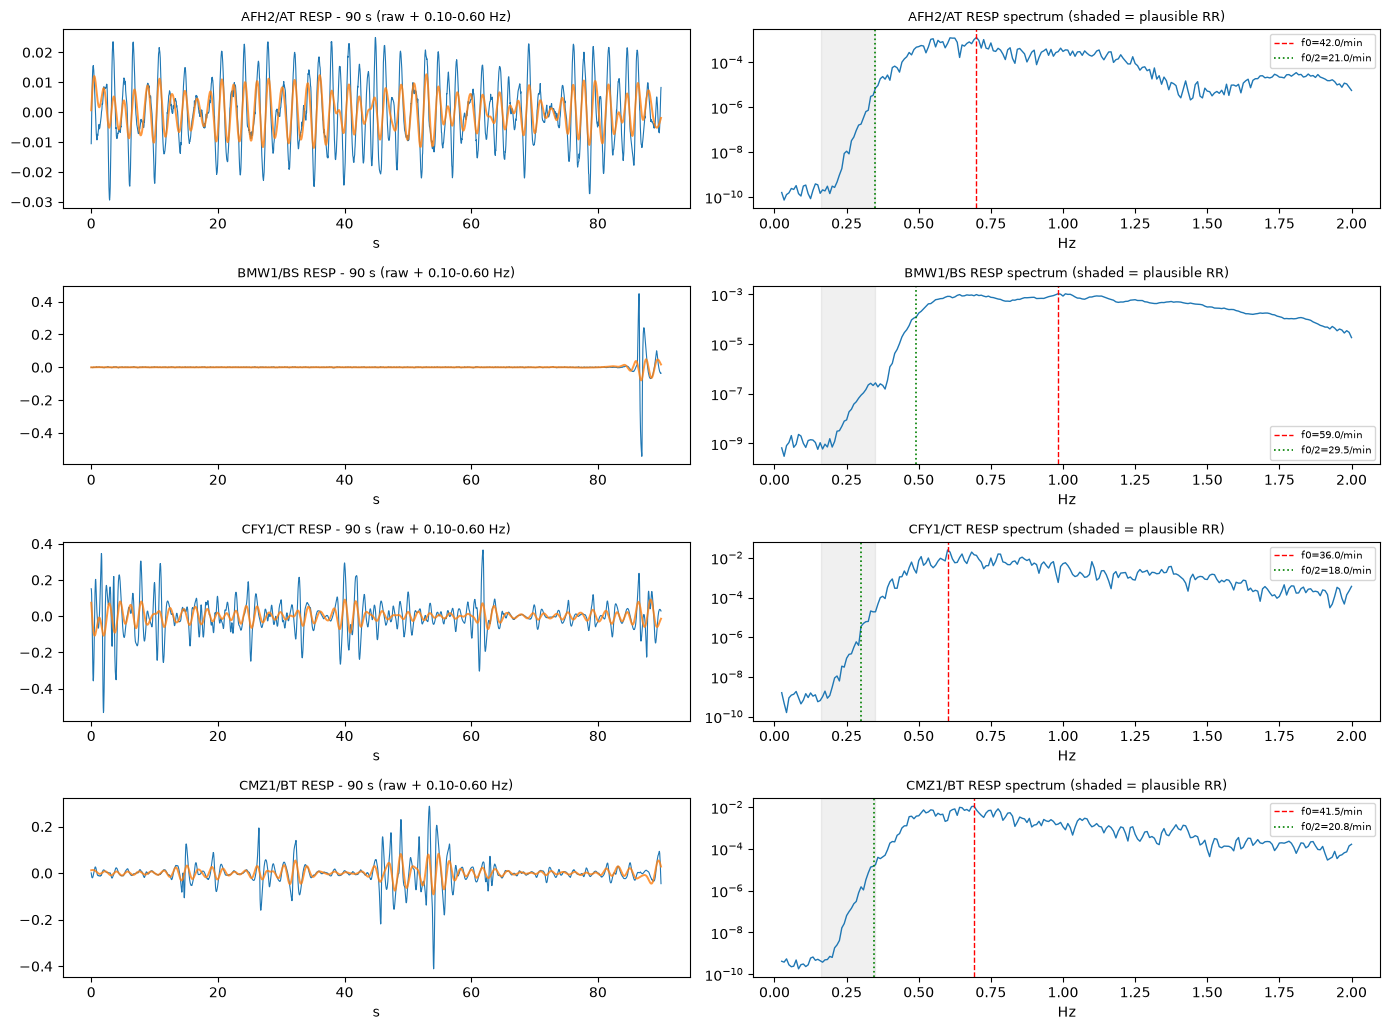

  ...100
  ...200

=== Corpus-wide (widened 0.08-1.2 Hz search, no edge clipping) ===
                     min        25%        50%        75%        max
f0_bpm         28.000000  34.000000  36.500000  40.000000  60.000000
half_bpm       14.000000  17.000000  18.250000  20.000000  30.000000
half_ratio      0.000001   0.000163   0.000667   0.003307   0.335816
count_rate     23.225806  30.508475  31.034483  31.578947  32.727273
count_rate_lo  11.285266  12.456747  12.903226  13.333333  16.438356

f0 histogram (/min):
     4-  8:  0
     8- 12:  0
    12- 16:  0
    16- 20:  0
    20- 24:  0
    24- 28:  0
    28- 32: ########## 32
    32- 36: ############################# 89
    36- 40: ############################## 90
    40- 44: ############## 43
    44- 48: ###### 20
    48- 52: # 3
    52- 56:  0
    56- 60:  1
    60- 64: # 5
    64- 68:  0
    68- 72:  0

Is f0 a harmonic?  (half_ratio = power at f0/2 relative to f0)
strong subharmonic (>0.5): 0.0%
present (>0.2): 1.4%
absent (<0

In [5]:
def spec(x, fs=FS, win_s=120):
    x = detrend(np.asarray(x, float))
    nper = int(min(len(x), fs * win_s))
    f, P = welch(x, fs=fs, nperseg=nper, noverlap=nper // 2)
    return f, P

def peak_in(f, P, lo, hi):
    m = (f >= lo) & (f <= hi)
    if not m.any():
        return np.nan, 0.0
    i = np.argmax(P[m])
    return f[m][i], P[m][i]

def local_power(f, P, f0, tol=0.025):
    m = (f >= f0 - tol) & (f <= f0 + tol)
    return P[m].max() if m.any() else 0.0

def count_rate(x, lo=0.10, hi=0.60, fs=FS):
    """FFT-independent rate: peak counting on a band-limited trace."""
    xb = bandpass(np.asarray(x, float), lo, hi, fs)
    pk, _ = find_peaks(xb, distance=int(fs / hi))
    if len(pk) < 3:
        return np.nan
    return 60.0 / (np.median(np.diff(pk)) / fs)

#  1 + 2: identity check and harmonic test on the probe 
P_ = PHYS_DIR / 'AFH2' / 'AT' / 'Label'
resp = read_sig(P_ / 'RESP.mat'); ecg = read_sig(P_ / 'ECG.mat'); bvp = read_sig(P_ / 'BVP.mat')
print('=== Identity check (is RESP a duplicated cardiac channel?) ===')
print(f'corr(RESP, ECG) = {np.corrcoef(resp, ecg)[0,1]:+.4f}   '
      f'identical={np.allclose(resp, ecg)}')
print(f'corr(RESP, BVP) = {np.corrcoef(resp, bvp)[0,1]:+.4f}   '
      f'identical={np.allclose(resp, bvp)}')

f, P = spec(resp)
f0, p0 = peak_in(f, P, 0.08, 1.2)
print(f'\n=== Harmonic test (probe) ===')
print(f'dominant peak  f0   = {f0:.4f} Hz = {f0*60:.1f} /min')
print(f'half-frequency f0/2 = {f0/2:.4f} Hz = {f0*30:.1f} /min')
for name, ff in [('f0/2', f0/2), ('f0', f0), ('2*f0', 2*f0), ('3*f0/2', 1.5*f0)]:
    print(f'power at {name:<7} ({ff:.3f} Hz): {local_power(f, P, ff):.4e}')
print(f'peak-count rate (0.10-0.60 Hz): {count_rate(resp):.1f} /min')
print(f'peak-count rate (0.08-0.35 Hz): {count_rate(resp, 0.08, 0.35):.1f} /min')

#  3: morphology + spectra for a spread of recordings 
picks = [('AFH2', 'AT'), ('BMW1', 'BS'), ('CFY1', 'CT'), ('AMZ1' if (PHYS_DIR/'AMZ1').exists() else 'CMZ1', 'BT')]
picks = [(s, g) for s, g in picks if (PHYS_DIR / s / g / 'Label' / 'RESP.mat').exists()]

fig, axes = plt.subplots(len(picks), 2, figsize=(14, 2.6 * len(picks)))
axes = np.atleast_2d(axes)
for r, (s, g) in enumerate(picks):
    x = read_sig(PHYS_DIR / s / g / 'Label' / 'RESP.mat')
    seg = detrend(x[:int(FS * 90)])                       # 90 s window
    t = np.arange(len(seg)) / FS
    axes[r, 0].plot(t, seg, lw=0.8)
    axes[r, 0].plot(t, bandpass(seg, 0.10, 0.60), lw=1.4, alpha=0.8)
    axes[r, 0].set_title(f'{s}/{g} RESP - 90 s (raw + 0.10-0.60 Hz)', fontsize=9)
    axes[r, 0].set_xlabel('s')

    ff, PP = spec(x)
    m = (ff >= 0.02) & (ff <= 2.0)
    axes[r, 1].semilogy(ff[m], PP[m], lw=1.0)
    fp, _ = peak_in(ff, PP, 0.08, 1.2)
    axes[r, 1].axvline(fp, color='r', ls='--', lw=1, label=f'f0={fp*60:.1f}/min')
    axes[r, 1].axvline(fp / 2, color='g', ls=':', lw=1.2, label=f'f0/2={fp*30:.1f}/min')
    axes[r, 1].axvspan(0.16, 0.35, color='k', alpha=0.06)  # 10-21 /min plausible
    axes[r, 1].legend(fontsize=7); axes[r, 1].set_xlabel('Hz')
    axes[r, 1].set_title(f'{s}/{g} RESP spectrum (shaded = plausible RR)', fontsize=9)
plt.tight_layout(); plt.show()

#  corpus-wide harmonic + peak-count test 
rows = []
for i, r in enumerate([x for x in df_seg.itertuples() if x.present]):
    try:
        x = read_sig(PHYS_DIR / r.subject / r.segment / 'Label' / 'RESP.mat')
        ff, PP = spec(x)
        f0, p0 = peak_in(ff, PP, 0.08, 1.2)
        p_half = local_power(ff, PP, f0 / 2) if f0 / 2 >= 0.05 else 0.0
        rows.append({
            'subject': r.subject, 'segment': r.segment, 'road': r.road, 'action': r.action,
            'f0_bpm': f0 * 60,
            'half_bpm': f0 * 30,
            'half_ratio': p_half / p0 if p0 else np.nan,
            'count_rate': count_rate(x, 0.10, 0.60),
            'count_rate_lo': count_rate(x, 0.08, 0.35),
        })
    except Exception as e:
        rows.append({'subject': r.subject, 'segment': r.segment, 'err': repr(e)[:80]})
    if (i + 1) % 100 == 0:
        print(f'  ...{i+1}')

h = pd.DataFrame(rows)
print('\n=== Corpus-wide (widened 0.08-1.2 Hz search, no edge clipping) ===')
print(h[['f0_bpm', 'half_bpm', 'half_ratio', 'count_rate', 'count_rate_lo']]
      .describe().T[['min', '25%', '50%', '75%', 'max']].to_string())

print('\nf0 histogram (/min):')
cnt, edg = np.histogram(h.f0_bpm.dropna(), bins=np.arange(4, 76, 4))
for c, e in zip(cnt, edg): print(f'   {e:>3.0f}-{e+4:>3.0f}: {"#" * int(c/3)} {c}')

print('\nIs f0 a harmonic?  (half_ratio = power at f0/2 relative to f0)')
print(f'strong subharmonic (>0.5): {(h.half_ratio > 0.5).mean()*100:.1f}%')
print(f'present (>0.2): {(h.half_ratio > 0.2).mean()*100:.1f}%')
print(f'absent (<0.1): {(h.half_ratio < 0.1).mean()*100:.1f}%')

print('\nPlausibility of each candidate rate (10-22 /min):')
for c in ['f0_bpm', 'half_bpm', 'count_rate', 'count_rate_lo']:
    print(f'   {c:<14} {h[c].between(10, 22).mean()*100:5.1f}%   median={h[c].median():.1f}')

print('\nDoes the candidate rate vary with the speaking condition (it should)?')
print(h.groupby(['road', 'action'])[['f0_bpm', 'half_bpm', 'count_rate_lo']]
      .median().round(2).to_string())
print('\nBetween-subject spread of half_bpm (real physiology varies):')
print(h.groupby('subject').half_bpm.median().describe().to_string())

#  4: RSA cross-check, independent of the RESP channel 
print('\n=== RSA check on 20 recordings (uses BVP only) ===')
sample = h.dropna(subset=['f0_bpm']).sample(min(20, len(h)), random_state=0)
rsa_rows = []
for r in sample.itertuples():
    lab = PHYS_DIR / r.subject / r.segment / 'Label'
    b = bandpass(read_sig(lab / 'BVP.mat'), 0.7, 3.0)
    pk, _ = find_peaks(b, distance=int(FS / 3.0))
    if len(pk) < 30:
        continue
    ibi_t, ibi = pk[1:] / FS, np.diff(pk) / FS
    keep = (ibi > 0.3) & (ibi < 1.6) # drop ectopic/miss
    if keep.sum() < 30:
        continue
    tt = np.arange(ibi_t[keep][0], ibi_t[keep][-1], 1 / 4.0)   # 4 Hz tachogram
    tach = np.interp(tt, ibi_t[keep], ibi[keep])
    ff, PP = welch(detrend(tach), fs=4.0, nperseg=int(min(len(tach), 4 * 120)))
    f_rsa, _ = peak_in(ff, PP, 0.12, 0.60)
    rsa_rows.append({'subject': r.subject, 'segment': r.segment,
                     'rsa_bpm': f_rsa * 60, 'resp_f0_bpm': r.f0_bpm,
                     'resp_half_bpm': r.half_bpm})
rsa = pd.DataFrame(rsa_rows)
print(rsa.round(2).to_string(index=False))
if len(rsa):
    print(f'\nRSA median {rsa.rsa_bpm.median():.1f} /min')
    print(f'|RSA - f0| median {np.abs(rsa.rsa_bpm - rsa.resp_f0_bpm).median():.2f}')
    print(f'|RSA - f0/2| median {np.abs(rsa.rsa_bpm - rsa.resp_half_bpm).median():.2f}')
    print('-> whichever is smaller identifies the true respiration rate')

h_df = h

### Is the respiration band filtered out, and does anything survive?

Previous step rejected the simple harmonic hypothesis: power at f0/2 is below 10% of the
peak in 97.5% of recordings, so the 36 /min median is not the second harmonic of a
visible 18 /min fundamental. Three apparently supportive statistics were artifacts
and are discarded: half_bpm is f0/2 by construction and therefore plausible by
arithmetic rather than by evidence; the peak-counting rates reproduce the centre
frequency of their own passbands; and the RSA estimates clustered on the 0.12 Hz
lower edge of the search band.

The spectra instead show a one-sided collapse of 6-7 orders of magnitude below
roughly 0.4 Hz. Broadband transients would elevate all frequencies uniformly and
per-recording min-max normalization preserves spectral shape, so neither accounts for
a low-frequency cliff. The leading explanation is that the released RESP channel was
high-passed with a cutoff above the respiration band, removing the signal of
interest. This mirrors the UBFC-rPPG contact PPG, which was bandpassed 0.5-8.0 Hz and
thereby stripped of respiratory content.

One rescue path remains. In the probe recording, power at 0.70 Hz and 1.05 Hz stands
in a 3:2 ratio while 1.40 Hz is negligible, which is the signature of the second and
third harmonics of a suppressed 0.35 Hz fundamental, equal to 21 breaths/min.
Respiration may therefore persist in harmonics that fall above the filter cutoff, and
in the amplitude modulation of the surviving high-frequency content.

This step runs four tests:

1. **Filter characterization.** Log-log spectra across 0.005-15 Hz identify whether
   the low-frequency rolloff has the sharp knee of a deliberate filter or the gentle
   slope of a physical measurement.
2. **Harmonic comb search, with a null control.** A candidate fundamental is scored
   by the power at its second and third harmonics, ignoring the filtered fundamental.
   Because a broad smooth plateau would make any comb score well, an off-harmonic
   comb at 2.3x and 3.7x serves as a control; the harmonic comb must beat it for the
   result to mean anything.
3. **Amplitude demodulation.** Respiration commonly survives as amplitude modulation.
   The Hilbert envelope of the 0.5-2.0 Hz band is searched for a 0.1-0.5 Hz component.
4. **Independent confirmation from BVP.** RIIV and RIAV are extracted from the
   fingertip BVP, a physically separate sensor from the chest belt. Because no
   trusted respiration reference exists in this dataset, agreement between belt-derived
   and BVP-derived rates is the only non-circular evidence available. Band-edge
   pinning is flagged explicitly throughout so that no estimate is read as a
   measurement when it is merely a boundary.

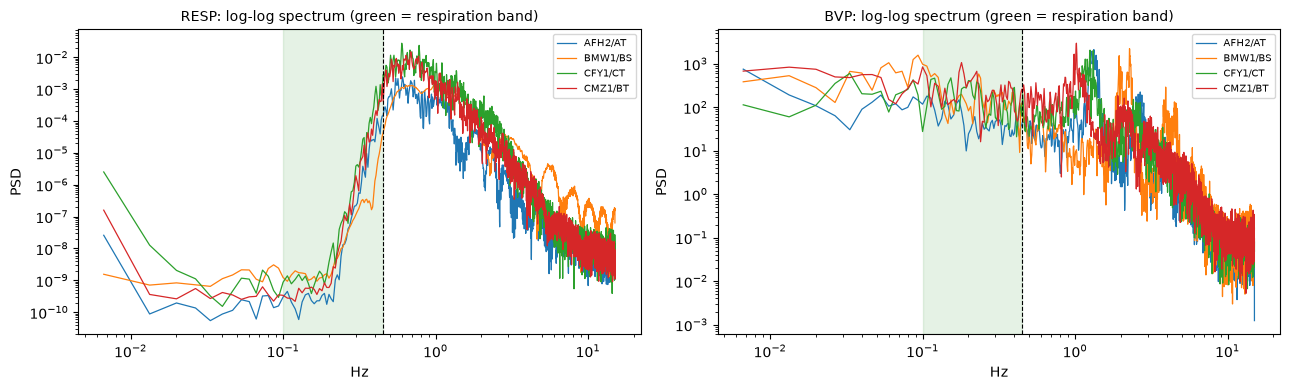

Reading: a sharp knee near 0.4-0.5 Hz in RESP but not BVP indicates a filter
applied to the belt channel specifically, rather than a physical property.

  ...100
  ...200

=== 1. Rolloff: plateau (0.6-1.5 Hz) over respiration band (0.15-0.40 Hz) ===
count    283.000000
mean       1.813194
std        0.385950
min        0.136300
25%        1.643410
50%        1.858017
75%        2.053773
max        3.791284
recordings with >3 decades of suppression: 0.4%
(>3 decades is far beyond any plausible physiological rolloff)

=== 2. Harmonic comb vs off-harmonic null control ===
                      min       25%        50%        75%         max
comb_rr         12.300000  15.00000  16.200000  17.400000   20.700000
comb_advantage  -0.245641   0.00000   0.086207   0.177355    0.567671
comb_contrast    2.651686  11.50312  16.485060  28.885136  196.103043
comb beats null control (advantage>0): 74.6%
comb pinned to grid edge:              0.0%
NOTE: if the advantage is ~0 the plateau is smooth and 

In [6]:
def full_spec(x, fs=FS, win_s=150):
    x = detrend(np.asarray(x, float))
    nper = int(min(len(x), fs * win_s))
    f, P = welch(x, fs=fs, nperseg=nper, noverlap=nper // 2)
    return f[1:], P[1:]

def band_stats(f, P, lo, hi, edge_tol=0.01):
    m = (f >= lo) & (f <= hi)
    if not m.any():
        return dict(peak=np.nan, snr=np.nan, at_edge=True)
    fb, Pb = f[m], P[m]
    fp = fb[np.argmax(Pb)]
    return dict(peak=fp,
                snr=float(Pb.max() / np.median(Pb)),
                at_edge=bool(fp <= lo + edge_tol or fp >= hi - edge_tol))

#  1: filter characterization 
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for s, g in picks:
    lab = PHYS_DIR / s / g / 'Label'
    for j, sig_name in enumerate(['RESP', 'BVP']):
        f, P = full_spec(read_sig(lab / f'{sig_name}.mat'))
        ax[j].loglog(f, P, lw=0.9, label=f'{s}/{g}')
for j, nm in enumerate(['RESP', 'BVP']):
    ax[j].axvspan(0.10, 0.45, color='g', alpha=0.10)
    ax[j].axvline(0.45, color='k', ls='--', lw=0.8)
    ax[j].set_title(f'{nm}: log-log spectrum (green = respiration band)', fontsize=10)
    ax[j].set_xlabel('Hz'); ax[j].set_ylabel('PSD'); ax[j].legend(fontsize=7)
plt.tight_layout(); plt.show()
print('Reading: a sharp knee near 0.4-0.5 Hz in RESP but not BVP indicates a filter')
print('applied to the belt channel specifically, rather than a physical property.\n')

#  2-4: corpus-wide 
FC_GRID = np.arange(0.10, 0.501, 0.005)

def comb_score(f, P, fc, mults):
    return float(np.prod([max(local_power(f, P, fc * m, tol=0.02), 1e-30) for m in mults]))

rows = []
for i, r in enumerate([x for x in df_seg.itertuples() if x.present]):
    lab = PHYS_DIR / r.subject / r.segment / 'Label'
    try:
        resp = read_sig(lab / 'RESP.mat')
        bvp  = read_sig(lab / 'BVP.mat')
        rec = {'subject': r.subject, 'segment': r.segment,
               'road': r.road, 'action': r.action, 'lighting': r.lighting}

        f, P = full_spec(resp)
        # rolloff: how far below the plateau is the respiration band?
        pl = P[(f >= 0.6) & (f <= 1.5)].mean()
        rb = P[(f >= 0.15) & (f <= 0.40)].mean()
        rec['rolloff_decades'] = np.log10(pl / rb) if rb > 0 else np.inf

        # harmonic comb vs off-harmonic null control
        harm = np.array([comb_score(f, P, fc, [2, 3]) for fc in FC_GRID])
        null = np.array([comb_score(f, P, fc, [2.3, 3.7]) for fc in FC_GRID])
        rec['comb_rr'] = FC_GRID[np.argmax(harm)] * 60
        rec['comb_at_edge'] = bool(np.argmax(harm) in (0, len(FC_GRID) - 1))
        rec['comb_advantage'] = float(np.log10(harm.max() / max(null.max(), 1e-30)))
        rec['comb_contrast']  = float(harm.max() / max(np.median(harm), 1e-30))

        # amplitude demodulation of the surviving band
        env = np.abs(hilbert(bandpass(resp, 0.5, 2.0)))
        fe, Pe = full_spec(env)
        st = band_stats(fe, Pe, 0.10, 0.50)
        rec['env_rr'], rec['env_snr'], rec['env_edge'] = st['peak'] * 60, st['snr'], st['at_edge']

        # independent BVP: RIAV (pulse amplitude) and RIIV (baseline)
        benv = np.abs(hilbert(bandpass(bvp, 0.7, 3.0)))
        fb_, Pb_ = full_spec(benv)
        st = band_stats(fb_, Pb_, 0.10, 0.50)
        rec['riav_rr'], rec['riav_snr'], rec['riav_edge'] = st['peak'] * 60, st['snr'], st['at_edge']

        base = bandpass(bvp, 0.10, 0.50)
        fbb, Pbb = full_spec(base)
        st = band_stats(fbb, Pbb, 0.12, 0.48)
        rec['riiv_rr'], rec['riiv_snr'], rec['riiv_edge'] = st['peak'] * 60, st['snr'], st['at_edge']
        rows.append(rec)
    except Exception as e:
        rows.append({'subject': r.subject, 'segment': r.segment, 'err': repr(e)[:90]})
    if (i + 1) % 100 == 0:
        print(f'  ...{i+1}')

z = pd.DataFrame(rows)
ok = z[z.get('err').isna()] if 'err' in z else z

print('\n=== 1. Rolloff: plateau (0.6-1.5 Hz) over respiration band (0.15-0.40 Hz) ===')
print(ok.rolloff_decades.describe().to_string())
print(f'recordings with >3 decades of suppression: {(ok.rolloff_decades > 3).mean()*100:.1f}%')
print('(>3 decades is far beyond any plausible physiological rolloff)')

print('\n=== 2. Harmonic comb vs off-harmonic null control ===')
print(ok[['comb_rr', 'comb_advantage', 'comb_contrast']].describe().T
      [['min', '25%', '50%', '75%', 'max']].to_string())
print(f'comb beats null control (advantage>0): {(ok.comb_advantage > 0).mean()*100:.1f}%')
print(f'comb pinned to grid edge:              {ok.comb_at_edge.mean()*100:.1f}%')
print('NOTE: if the advantage is ~0 the plateau is smooth and the comb is meaningless.')

print('\n=== 3-4. Rate estimates and band-edge pinning ===')
for c, e in [('env_rr', 'env_edge'), ('riav_rr', 'riav_edge'), ('riiv_rr', 'riiv_edge')]:
    v = ok[c]
    print(f'{c:<9} median={v.median():6.1f}  IQR={v.quantile(.25):.1f}-{v.quantile(.75):.1f}'
          f'in 10-22/min={v.between(10,22).mean()*100:5.1f}%  AT EDGE={ok[e].mean()*100:5.1f}%'
          f'median SNR={ok[c.replace("_rr","_snr")].median():.2f}')

print('\n=== THE DECISIVE TEST: do independent sensors agree? ===')
clean = ok[~ok.env_edge & ~ok.riav_edge]
print(f'recordings where neither estimator is pinned: {len(clean)} / {len(ok)}')
if len(clean) > 10:
    for a, b in [('env_rr', 'riav_rr'), ('env_rr', 'riiv_rr'), ('riav_rr', 'riiv_rr')]:
        d = (clean[a] - clean[b]).abs()
        r = np.corrcoef(clean[a], clean[b])[0, 1]
        print(f'{a} vs {b}: median|diff|={d.median():5.2f}/min  within 2/min='
              f'{(d <= 2).mean()*100:5.1f}%  r={r:+.3f}')
    print('\n  Chance baseline: two independent draws from this range would agree')
    print('within 2/min about 15-20% of the time. Agreement must clearly exceed that.')
    print(f'comb_rr vs env_rr: median|diff|='
          f'{(clean.comb_rr - clean.env_rr).abs().median():.2f}/min')

print('\n=== Does any estimate respond to the speaking condition? ===')
print(ok.groupby('action')[['comb_rr', 'env_rr', 'riav_rr']].median().round(2).to_string())
print('\nBetween-subject spread (physiology should vary more than method noise):')
print(ok.groupby('subject')[['env_rr', 'riav_rr']].median().std().round(2).to_string())

z_df = z

### Falsifying the comb result and validating the estimators

Three claims from previous steps require verification before any conclusion is recorded.

**Claim 1: the harmonic comb is not measuring respiration.** Its 0.086-decade
advantage over the off-harmonic null is a 22% margin, and its output range is
suspiciously consistent with a purely geometric explanation: for a spectrum with a
single plateau peak near 0.7 Hz, aligning the second harmonic implies a fundamental
of 0.35 Hz and aligning the third implies 0.233 Hz, so a product score peaks between
them near 16 breaths/min regardless of physiology. If comb_rr is a deterministic
function of the plateau peak f0, it carries no independent information. Correlating
the two settles it.

**Claim 2: the reported cross-sensor agreement is at chance.** The 47% of pairs
agreeing within 2 /min was compared against an assumed 15-20% baseline, which is
wrong for distributions concentrated in a narrow region near a band edge. A
permutation test that shuffles the pairing between recordings gives the correct null.

**Claim 3: the failure lies in the data, not in the estimators.** This is the
distinction that separates an honest negative from a broken pipeline. A synthetic
respiration signal of known rate is passed through the estimators twice: once
unfiltered, where recovery must succeed, and once after a high-pass matching the one
inferred from the released RESP channel, where failure would demonstrate that the
information has been destroyed rather than merely missed. A synthetic
amplitude-modulated pulse wave provides the same control for the envelope and RIAV
estimators.

In [7]:
from scipy.signal import butter as _butter

#  Claim 1: is comb_rr just a restatement of f0? 
m = z_df.merge(h_df[['subject', 'segment', 'f0_bpm']], on=['subject', 'segment'])
m = m.dropna(subset=['comb_rr', 'f0_bpm'])
r_comb = np.corrcoef(m.comb_rr, m.f0_bpm)[0, 1]
ratio = m.f0_bpm / m.comb_rr
print('=== Claim 1: comb_rr vs f0_bpm ===')
print(f'r = {r_comb:+.4f}   (near +1 => comb_rr is a relabeling of the plateau peak)')
print(f'f0/comb_rr ratio: median={ratio.median():.3f}  IQR={ratio.quantile(.25):.3f}-'
      f'{ratio.quantile(.75):.3f}  std={ratio.std():.3f}')
print(f'(a tight ratio between 2 and 3 confirms the geometric explanation)')

#  Claim 2: permutation baseline for cross-sensor agreement 
print('\n=== Claim 2: permutation test on cross-sensor agreement ===')
cl = z_df[~z_df.env_edge & ~z_df.riav_edge].dropna(subset=['env_rr', 'riav_rr'])
obs_within = float((np.abs(cl.env_rr - cl.riav_rr) <= 2).mean())
obs_med = float(np.abs(cl.env_rr - cl.riav_rr).median())
rng = np.random.default_rng(0)
a, b = cl.env_rr.to_numpy(), cl.riav_rr.to_numpy()
null_w, null_m = [], []
for _ in range(2000):
    bs = rng.permutation(b)
    null_w.append((np.abs(a - bs) <= 2).mean())
    null_m.append(np.median(np.abs(a - bs)))
null_w, null_m = np.array(null_w), np.array(null_m)
p_w = (null_w >= obs_within).mean()
p_m = (null_m <= obs_med).mean()
print(f'n={len(cl)}')
print(f'within-2/min: observed {obs_within*100:.1f}%   '
      f'shuffled null {null_w.mean()*100:.1f}% (95% {np.percentile(null_w,2.5)*100:.1f}-'
      f'{np.percentile(null_w,97.5)*100:.1f}%)   p={p_w:.4f}')
print(f'median|diff|: observed {obs_med:.2f}      '
      f'shuffled null {null_m.mean():.2f} ({np.percentile(null_m,2.5):.2f}-'
      f'{np.percentile(null_m,97.5):.2f})   p={p_m:.4f}')
print('-> p well above 0.05 means the apparent agreement is entirely chance')

#  Claim 3: positive control 
print('\n=== Claim 3: positive control - can these estimators find a KNOWN rate? ===')
TRUE_RR = 15.0 # breaths/min
fr = TRUE_RR / 60
n = int(FS * 300)
t = np.arange(n) / FS

def hp(x, fc=0.45, order=4, fs=FS):
    bb, aa = _butter(order, fc / (fs / 2), btype='high')
    return filtfilt(bb, aa, x)

def estimate_all(sig_resp, sig_pulse=None):
    out = {}
    f, P = full_spec(sig_resp)
    harm = np.array([comb_score(f, P, fc, [2, 3]) for fc in FC_GRID])
    out['comb'] = FC_GRID[np.argmax(harm)] * 60
    st = band_stats(*full_spec(np.abs(hilbert(bandpass(sig_resp, 0.5, 2.0)))), 0.10, 0.50)
    out['env'] = st['peak'] * 60
    st = band_stats(*full_spec(sig_resp), 0.10, 0.50)
    out['direct'] = st['peak'] * 60
    if sig_pulse is not None:
        st = band_stats(*full_spec(np.abs(hilbert(bandpass(sig_pulse, 0.7, 3.0)))), 0.10, 0.50)
        out['riav'] = st['peak'] * 60
    return out

rng2 = np.random.default_rng(1)
# a realistic belt trace: non-sinusoidal breathing + drift + noise
breath = (np.sin(2*np.pi*fr*t) + 0.35*np.sin(2*np.pi*2*fr*t + 0.7) + 0.15*np.sin(2*np.pi*3*fr*t + 1.3))
belt_clean = breath + 0.4*np.sin(2*np.pi*0.02*t) + 0.15*rng2.standard_normal(n)
# a pulse wave amplitude-modulated by respiration (RIAV substrate)
pulse = (1 + 0.25*np.sin(2*np.pi*fr*t)) * np.sin(2*np.pi*1.3*t) + 0.05*rng2.standard_normal(n)

print(f'  ground truth = {TRUE_RR:.1f} /min\n')
for label, sig_, pul in [('UNFILTERED  (must succeed)', belt_clean, pulse),
                         ('HIGH-PASSED (0.45 Hz, as inferred)', hp(belt_clean), hp(pulse))]:
    est = estimate_all(sig_, pul)
    line = '   '.join(f'{k}={v:5.1f}' for k, v in est.items())
    errs = {k: abs(v - TRUE_RR) for k, v in est.items()}
    print(f'{label}')
    print(f'{line}')
    print(f'|error|: ' + '  '.join(f'{k}={v:.1f}' for k, v in errs.items()))
    print(f'recovered within 2/min: {sum(e <= 2 for e in errs.values())}/{len(errs)}\n')

print(' Interpretation:')
print(' - unfiltered recovers 15 but high-passed does not => the estimators are sound')
print(' and the respiratory information has been destroyed in the release.')
print(' - if the unfiltered case ALSO fails, the estimators are at fault and the')
print(' PhysDrive RESP conclusion must be withheld.')

#  how steep is the inferred filter, really? 
print('\n=== Inferred filter knee from real recordings ===')
knees = []
for s, g in picks:
    f, P = full_spec(read_sig(PHYS_DIR / s / g / 'Label' / 'RESP.mat'))
    plateau = P[(f >= 0.6) & (f <= 1.2)].max()
    below = f[(f > 0.02) & (P < plateau / 1000)]      # -30 dB point
    if below.size:
        knees.append(below.max())
        print(f'  {s}/{g}: -30 dB point at {below.max():.3f} Hz = {below.max()*60:.1f} /min')
print(f'median knee {np.median(knees):.3f} Hz' if knees else '')
print('A knee inside 0.3-0.5 Hz sits directly on top of normal adult breathing.')

=== Claim 1: comb_rr vs f0_bpm ===
r = +0.2931   (near +1 => comb_rr is a relabeling of the plateau peak)
f0/comb_rr ratio: median=2.193  IQR=2.049-2.477  std=0.349
(a tight ratio between 2 and 3 confirms the geometric explanation)

=== Claim 2: permutation test on cross-sensor agreement ===
n=142
within-2/min: observed 47.2%   shuffled null 46.6% (95% 40.1-52.8%)   p=0.4785
median|diff|: observed 2.00      shuffled null 2.24 (2.00-2.80)   p=0.3895
-> p well above 0.05 means the apparent agreement is entirely chance

=== Claim 3: positive control - can these estimators find a KNOWN rate? ===
  ground truth = 15.0 /min

UNFILTERED  (must succeed)
comb= 14.7   env= 14.8   direct= 14.8   riav= 15.2
|error|: comb=0.3  env=0.2  direct=0.2  riav=0.2
recovered within 2/min: 4/4

HIGH-PASSED (0.45 Hz, as inferred)
comb= 14.7   env= 14.8   direct= 30.0   riav= 15.2
|error|: comb=0.3  env=0.2  direct=15.0  riav=0.2
recovered within 2/min: 3/4

 Interpretation:
 - unfiltered recovers 15 but high-

### What is the RESP channel actually measuring?

The previous step positive control refuted the working mechanism. A 0.45 Hz high-pass
applied to a synthetic 15 breaths/min belt trace still permitted recovery by the
comb, envelope and RIAV estimators to within 0.3 /min; only the direct spectral peak
failed. Since those same estimators return nothing on the released RESP channel, the
absence of a fundamental cannot by itself explain the result.

Two findings from previous step stand. The permutation test confirms the cross-sensor
agreement is chance (observed 47.2% within 2 /min against a shuffled null of 46.6%,
p=0.48), so the negative result is rigorous. And the estimators are validated as both
correct and filter-robust, which locates the problem in the data rather than the
method. A code defect is also corrected here: the earlier -30 dB knee search selected
the highest sub-threshold frequency and therefore reported the Nyquist tail at 15 Hz
for every recording instead of the low-frequency cutoff.

The open question is what the channel contains. Its energy forms a broad plateau
between roughly 0.6 and 1.5 Hz, peaking near 0.7 Hz, which is approximately half the
corpus median heart rate of about 80 bpm. Three hypotheses are tested:

1. **Cardiac or ballistic origin.** If the plateau peak tracks each recording's heart
   rate, the belt is registering pulsatile or ballistocardiographic motion rather than
   breathing. A per-recording correlation between the plateau peak and the masked HR
   label distinguishes this from coincidence, and the ratio distribution indicates
   whether the relationship is at the fundamental, the half, or absent.
2. **Processing more aggressive than modelled.** A cutoff sweep establishes how
   severe a filter must be before the comb and envelope estimators fail on a known
   synthetic rate. If no plausible cutoff reproduces the observed behaviour, filtering
   is ruled out as a sufficient explanation.
3. **Duplication or placeholder content.** Byte-level and array-level comparison
   across segments and subjects tests whether RESP files repeat, which would indicate
   a packaging fault rather than a measurement.

In [8]:
def knee_hz(x, drop_db=30):
    """Lowest-frequency -N dB point BELOW the plateau peak (previous version took
    the Nyquist tail because it searched the whole spectrum)."""
    f, P = full_spec(x)
    band = (f >= 0.3) & (f <= 2.0)
    fpk = f[band][np.argmax(P[band])]
    thr = P[band].max() / (10 ** (drop_db / 10))
    left = (f < fpk) & (f > 0.01)
    below = f[left & (P < thr)]
    return (below.max() if below.size else np.nan), fpk

print('=== Corrected knee detection ===')
for s, g in picks:
    k, fpk = knee_hz(read_sig(PHYS_DIR / s / g / 'Label' / 'RESP.mat'))
    print(f'{s}/{g}: plateau peak {fpk:.3f} Hz ({fpk*60:.1f}/min), '
          f'-30 dB knee at {k:.3f} Hz ({k*60:.1f}/min)')

#  H1: does the plateau track heart rate? 
print('\n=== H1: is the RESP plateau cardiac-linked? ===')
hr_ref = good[['subject', 'segment', 'hr_ref_mean', 'bvp_hr_bpm', 'hr_bad_frac']]
mm = h_df[['subject', 'segment', 'f0_bpm']].merge(hr_ref, on=['subject', 'segment'])
mm = mm[(mm.hr_bad_frac < 0.5)].dropna(subset=['f0_bpm', 'hr_ref_mean'])
r_hr = np.corrcoef(mm.f0_bpm, mm.hr_ref_mean)[0, 1]
rat = mm.hr_ref_mean / mm.f0_bpm
print(f'n={len(mm)}   corr(RESP plateau f0, HR) = {r_hr:+.4f}')
print(f'HR / f0 ratio: median={rat.median():.3f}  IQR={rat.quantile(.25):.3f}-'
      f'{rat.quantile(.75):.3f}  std={rat.std():.3f}')
print('ratio near 2.0 with high r => plateau is a cardiac subharmonic')
print('r near 0 => plateau is unrelated to heart rate (vibration/other)')
# control: same test against a shuffled HR pairing
rng3 = np.random.default_rng(3)
sh = [abs(np.corrcoef(mm.f0_bpm, rng3.permutation(mm.hr_ref_mean.to_numpy()))[0, 1])
      for _ in range(1000)]
print(f'  shuffled |r| 95th percentile = {np.percentile(sh, 95):.4f}  '
      f'=> observed |r|={abs(r_hr):.4f} is '
      f'{"SIGNIFICANT" if abs(r_hr) > np.percentile(sh, 95) else "not significant"}')

#  H2: how aggressive must filtering be to defeat the estimators? 
print('\n=== H2: cutoff sweep - what filter would reproduce what we observe? ===')
print(f'synthetic ground truth {TRUE_RR:.0f}/min')
print(f'{"cutoff":>8} {"order":>6} | {"comb":>6} {"env":>6} {"riav":>6} | recovered')
for fc_hp in [0.30, 0.45, 0.60, 0.80, 1.00, 1.50]:
    for order in [4, 8]:
        try:
            est = estimate_all(hp(belt_clean, fc_hp, order), hp(pulse, fc_hp, order))
        except Exception:
            continue
        got = sum(abs(est[k] - TRUE_RR) <= 2 for k in ['comb', 'env', 'riav'])
        print(f'  {fc_hp:>8.2f} {order:>6} | {est["comb"]:>6.1f} {est["env"]:>6.1f} '
              f'{est["riav"]:>6.1f} | {got}/3')
print('The real data yields 0/3. Any cutoff that also yields 0/3 is a candidate;')
print('if none does, filtering alone cannot explain the observation.')

#  H3: duplication / placeholder check 
print('\n=== H3: are RESP arrays duplicated across recordings? ===')
digests, stats_rows = {}, []
for r in [x for x in df_seg.itertuples() if x.present]:
    x = read_sig(PHYS_DIR / r.subject / r.segment / 'Label' / 'RESP.mat')
    d = hashlib.md5(np.ascontiguousarray(x).tobytes()).hexdigest()
    digests.setdefault(d, []).append(f'{r.subject}/{r.segment}')
    stats_rows.append({'subject': r.subject, 'segment': r.segment,
                       'std': x.std(), 'n_unique': len(np.unique(x)), 'n': len(x)})
dups = {k: v for k, v in digests.items() if len(v) > 1}
print(f'  distinct RESP arrays: {len(digests)} / {len(stats_rows)}')
print(f'  duplicated groups: {len(dups)}')
for k, v in list(dups.items())[:5]:
    print(f'{v}')
sdf = pd.DataFrame(stats_rows)
sdf['uniq_frac'] = sdf.n_unique / sdf.n
print('\n  value diversity (uniq_frac near 1.0 = genuine continuous signal):')
print(sdf.uniq_frac.describe().to_string())
print(f'recordings with uniq_frac < 0.5: {(sdf.uniq_frac < 0.5).sum()}')

#  sanity: does BVP carry respiration where RESP does not? 
print('\n=== Reference sanity: BVP low-frequency content is intact (Step 6 plot) ===')
print('If RIIV from BVP were reliable it would be the fallback RR source.')
print('Step 6 gave riiv_rr median 10.4/min with 15.5% at edge and r~0 vs other')
print('estimators, so it is not currently usable either - retested here after')
print('restricting to high-SNR recordings only:')
hi = z_df[(z_df.riiv_snr > z_df.riiv_snr.quantile(0.75)) & ~z_df.riiv_edge]
print(f'  n={len(hi)}  riiv_rr median={hi.riiv_rr.median():.1f}  '
      f'IQR={hi.riiv_rr.quantile(.25):.1f}-{hi.riiv_rr.quantile(.75):.1f}  '
      f'in 10-22/min={hi.riiv_rr.between(10,22).mean()*100:.1f}%')

=== Corrected knee detection ===
AFH2/AT: plateau peak 0.607 Hz (36.4/min), -30 dB knee at 0.347 Hz (20.8/min)
BMW1/BS: plateau peak 0.987 Hz (59.2/min), -30 dB knee at 0.400 Hz (24.0/min)
CFY1/CT: plateau peak 0.600 Hz (36.0/min), -30 dB knee at 0.347 Hz (20.8/min)
CMZ1/BT: plateau peak 0.687 Hz (41.2/min), -30 dB knee at 0.347 Hz (20.8/min)

=== H1: is the RESP plateau cardiac-linked? ===
n=282   corr(RESP plateau f0, HR) = +0.1968
HR / f0 ratio: median=2.146  IQR=1.869-2.483  std=0.427
ratio near 2.0 with high r => plateau is a cardiac subharmonic
r near 0 => plateau is unrelated to heart rate (vibration/other)
  shuffled |r| 95th percentile = 0.1143  => observed |r|=0.1968 is SIGNIFICANT

=== H2: cutoff sweep - what filter would reproduce what we observe? ===
synthetic ground truth 15/min
  cutoff  order |   comb    env   riav | recovered
      0.30      4 |   14.7   14.8   15.2 | 3/3
      0.30      8 |   14.7   14.8   15.2 | 3/3
      0.45      4 |   14.7   14.8   15.2 | 3/3
    

### Video geometry, true frame counts, and the S/T action mapping

Three questions remain that can change the preprocessing schema, and all three are
answered from the video streams rather than the labels.

**Frame count.** The probe showed an RGB header count of 12000 against an IR count
and label length of 11996. Header values from h264 containers are not authoritative,
so the true count is established by decoding. The distinction matters because it
determines whether the labels are frame-synced to RGB directly, or whether a
four-frame trim is required, and if so at which end. Since the labels match IR
exactly, the working assumption is that alignment was performed against the IR
stream.

**Face geometry.** Every other dataset in the corpus was captured at conversational
distance. PhysDrive is filmed from a dashboard mount with the driver further away,
and the RGB stream is only 1024x576 whereas IR is 1920x1080. If the face occupies
fewer than roughly 72 pixels in RGB, the committed 72x72 crop would be an upsample
rather than a downsample, which would make RGB the weaker modality despite being the
conventional choice for rPPG. Detection rate under in-vehicle lighting is measured at
the same time, since a face-crop pipeline that fails intermittently needs a fallback.

**Action mapping.** The segment codes S and T correspond to the paper's stationary
and speaking conditions, but which letter denotes which has not been established, and
the assignment matters for both stratified evaluation and any motion-robustness
analysis. Speaking produces mouth and lower-face movement that a stationary driver
does not, whereas road-induced shaking moves the whole head. The discriminator is
therefore the ratio of lower-face motion to forehead motion, which normalises out
global head movement. The comparison is made within subject and within road
condition, so that only the action variable differs.


In [9]:
pres = [r for r in df_seg.itertuples() if r.present]
rng4 = np.random.default_rng(7)

#  Part A: true frame counts by decode 
def true_count(path):
    cap = cv2.VideoCapture(str(path))
    hdr = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    n = 0
    while cap.grab(): # grab() skips colour conversion - much faster than read()
        n += 1
    cap.release()
    return hdr, n

N_COUNT = 6
sample_a = [pres[i] for i in rng4.choice(len(pres), N_COUNT, replace=False)]
print('=== Part A: header vs decoded frame count ===')
print(f'{"recording":<14} {"label_n":>8} {"rgb_hdr":>8} {"rgb_dec":>8} {"ir_hdr":>8} {"ir_dec":>8}')
fa = []
for r in sample_a:
    d = PHYS_DIR / r.subject / r.segment
    ln = len(read_sig(d / 'Label' / 'BVP.mat'))
    t0 = time.time()
    rh, rd = true_count(d / 'Video' / 'RGB.mp4')
    ih, idc = true_count(d / 'Video' / 'IR.mp4')
    print(f'{r.subject+"/"+r.segment:<14} {ln:>8} {rh:>8} {rd:>8} {ih:>8} {idc:>8}   '
          f'({time.time()-t0:.0f}s)')
    fa.append({'rec': f'{r.subject}/{r.segment}', 'label_n': ln,
               'rgb_hdr': rh, 'rgb_dec': rd, 'ir_hdr': ih, 'ir_dec': idc})
fa = pd.DataFrame(fa)
fa['rgb_dec_vs_label'] = fa.rgb_dec - fa.label_n
fa['ir_dec_vs_label']  = fa.ir_dec - fa.label_n
print('\nDeltas versus label length:')
print(fa[['rec', 'rgb_dec_vs_label', 'ir_dec_vs_label']].to_string(index=False))
print(f'\nRGB decoded == label in {(fa.rgb_dec_vs_label == 0).sum()}/{len(fa)}; '
      f'IR decoded == label in {(fa.ir_dec_vs_label == 0).sum()}/{len(fa)}')
print('If IR matches and RGB is consistently +4, the labels were aligned to IR and')
print('the RGB stream needs a documented trim rule.')


#  Part B: face geometry 
print('mediapipe version:', mp.__version__)
MODEL = Path(r'D:\code\QualityPhys - CRVSE Project\app\live_hr_demo\models'
             r'\mediapipe\face_landmarker.task')
print('landmarker model present:', MODEL.exists())

# FaceMesh landmark indices
IDX = dict(lip_up=13, lip_dn=14, corner_l=61, corner_r=291,
           top=10, chin=152, cheek_l=234, cheek_r=454)

def make_landmarker(video_mode=False):
    opts = vision.FaceLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=str(MODEL)),
        running_mode=vision.RunningMode.VIDEO if video_mode else vision.RunningMode.IMAGE,
        num_faces=1, min_face_detection_confidence=0.3,
        min_face_presence_confidence=0.3, min_tracking_confidence=0.3)
    return vision.FaceLandmarker.create_from_options(opts)

def to_mp(frame_bgr):
    return mp.Image(image_format=mp.ImageFormat.SRGB,
                    data=cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))

def lm_px(res, W, H):
    if not res.face_landmarks:
        return None
    p = res.face_landmarks[0]
    return np.array([[l.x * W, l.y * H] for l in p])


def sample_frames(path, k=15):
    cap = cv2.VideoCapture(str(path))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    out = []
    for i in np.linspace(n * 0.05, n * 0.95, k).astype(int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, fr = cap.read()
        if ok:
            out.append(fr)
    cap.release()
    return out

def face_stats(frames, label):
    lmk = make_landmarker(False)
    ws, hs, cx, cy, hits = [], [], [], [], 0
    for fr in frames:
        H, W = fr.shape[:2]
        pts = lm_px(lmk.detect(to_mp(fr)), W, H)
        if pts is None:
            continue
        hits += 1
        w = pts[:, 0].max() - pts[:, 0].min()
        h = pts[:, 1].max() - pts[:, 1].min()
        ws.append(w); hs.append(h)
        cx.append(pts[:, 0].mean()); cy.append(pts[:, 1].mean())
    lmk.close()
    if not ws:
        return {'stream': label, 'det_rate': 0.0, 'w_med': np.nan, 'h_med': np.nan,
                'w_min': np.nan, 'x_std': np.nan, 'y_std': np.nan}
    return {'stream': label, 'det_rate': hits / max(len(frames), 1),
            'w_med': float(np.median(ws)), 'h_med': float(np.median(hs)),
            'w_min': float(np.min(ws)), 'x_std': float(np.std(cx)),
            'y_std': float(np.std(cy))}

pres = [r for r in df_seg.itertuples() if r.present]
rng4 = np.random.default_rng(7)
N_FACE = 12
sample_b = [pres[i] for i in rng4.choice(len(pres), N_FACE, replace=False)]

print('\n=== Part B: face size and detection rate (72x72 crop target) ===')
rows = []
for r in sample_b:
    d = PHYS_DIR / r.subject / r.segment / 'Video'
    for nm, lab in [('RGB.mp4', 'RGB'), ('IR.mp4', 'IR')]:
        st = face_stats(sample_frames(d / nm), lab)
        st.update(rec=f'{r.subject}/{r.segment}', lighting=r.lighting, road=r.road)
        rows.append(st)
fb = pd.DataFrame(rows)
print(fb[['rec', 'lighting', 'stream', 'det_rate', 'w_med', 'h_med',
          'w_min', 'x_std', 'y_std']].round(1).to_string(index=False))
print('\nBy stream (median):')
print(fb.groupby('stream')[['det_rate', 'w_med', 'h_med', 'w_min']].median().round(1).to_string())
for s in fb.stream.unique():
    sub = fb[fb.stream == s].dropna(subset=['w_med'])
    print(f'  {s}: face width < 72 px in {(sub.w_med < 72).sum()}/{len(sub)};  '
          f'< 100 px in {(sub.w_med < 100).sum()}/{len(sub)};  '
          f'< 144 px (2x target) in {(sub.w_med < 144).sum()}/{len(sub)}')
print('\nDetection rate by lighting:')
print(fb.pivot_table(index='lighting', columns='stream', values='det_rate').round(2).to_string())

#  Part C: which letter is speaking? 
N_FRAMES_C = 240 # 8 s at 30 fps

def mouth_dynamics(path, k=N_FRAMES_C):
    """Variance of normalised lip aperture. Speaking opens and closes the mouth;
    road shaking moves the whole head without changing lip separation."""
    lmk = make_landmarker(True)
    cap = cv2.VideoCapture(str(path))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(n * 0.3))
    ap, wd, hits, t = [], [], 0, 0
    for _ in range(k):
        ok, fr = cap.read()
        if not ok:
            break
        H, W = fr.shape[:2]
        t += 33
        pts = lm_px(lmk.detect_for_video(to_mp(fr), t), W, H)
        if pts is None:
            continue
        hits += 1
        face_h = np.linalg.norm(pts[IDX['top']] - pts[IDX['chin']])
        if face_h < 1:
            continue
        ap.append(np.linalg.norm(pts[IDX['lip_up']] - pts[IDX['lip_dn']]) / face_h)
        wd.append(np.linalg.norm(pts[IDX['corner_l']] - pts[IDX['corner_r']]) / face_h)
    cap.release(); lmk.close()
    if len(ap) < 30:
        return dict(ap_std=np.nan, ap_mean=np.nan, ap_p90=np.nan,
                    wd_std=np.nan, det=hits / max(k, 1))
    ap = np.array(ap)
    return dict(ap_std=float(ap.std()), ap_mean=float(ap.mean()),
                ap_p90=float(np.percentile(ap, 90) - np.percentile(ap, 10)),
                wd_std=float(np.std(wd)), det=hits / max(k, 1))

print('\n=== Part C: S vs T - lip aperture dynamics ===')
pairs, done = [], set()
t0 = time.time()
for r in pres:
    if r.subject in done or len(done) >= 10:
        continue
    for road in ['A', 'B', 'C']:
        ps = PHYS_DIR / r.subject / f'{road}S' / 'Video' / 'RGB.mp4'
        pt = PHYS_DIR / r.subject / f'{road}T' / 'Video' / 'RGB.mp4'
        if ps.exists() and pt.exists():
            a, b = mouth_dynamics(ps), mouth_dynamics(pt)
            pairs.append({'subject': r.subject, 'road': road,
                          'apstd_S': a['ap_std'], 'apstd_T': b['ap_std'],
                          'p90_S': a['ap_p90'], 'p90_T': b['ap_p90'],
                          'det_S': a['det'], 'det_T': b['det']})
            done.add(r.subject)
            break
print(f'({time.time()-t0:.0f}s)')
pc = pd.DataFrame(pairs)
print(pc.round(4).to_string(index=False))
pc = pc.dropna(subset=['apstd_S', 'apstd_T'])
if len(pc):
    from scipy.stats import binomtest, wilcoxon
    k, nn = int((pc.apstd_T > pc.apstd_S).sum()), len(pc)
    p_sign = binomtest(k, nn, 0.5).pvalue
    print(f'\nT has larger lip-aperture variance in {k}/{nn} pairs  (sign test p={p_sign:.4f})')
    print(f'median ap_std   S={pc.apstd_S.median():.4f}   T={pc.apstd_T.median():.4f}')
    print(f'median p10-p90  S={pc.p90_S.median():.4f}   T={pc.p90_T.median():.4f}')
    try:
        print(f'Wilcoxon signed-rank p={wilcoxon(pc.apstd_S, pc.apstd_T).pvalue:.4f}')
    except Exception as e:
        print('Wilcoxon skipped:', e)
    if p_sign < 0.05:
        print('=> ' + ('T = Talking/speaking, S = Stationary' if k > nn / 2 else 'S = Speaking, T = sTationary'))
    else:
        print('=> inconclusive; widen to more subjects or sample multiple windows')
    print(f'\n  landmark detection rate: S={pc.det_S.median():.2f}  T={pc.det_T.median():.2f}')

fb_df, pc_df = fb, pc

=== Part A: header vs decoded frame count ===
recording       label_n  rgb_hdr  rgb_dec   ir_hdr   ir_dec
BMW2/CT            9046     9047     9047     9046     9046   (19s)
CFH1/CS           12960    12963    12963    12960    12960   (29s)
CMW1/CT            9087     9087     9087     9088     9088   (22s)
CMY1/BT            9685     9687     9687     9685     9685   (24s)
BMY2/CS            8758     8760     8760     8758     8758   (23s)
CFY2/BS            9060     9066     9066     9060     9060   (23s)

Deltas versus label length:
    rec  rgb_dec_vs_label  ir_dec_vs_label
BMW2/CT                 1                0
CFH1/CS                 3                0
CMW1/CT                 0                1
CMY1/BT                 2                0
BMY2/CS                 2                0
CFY2/BS                 6                0

RGB decoded == label in 1/6; IR decoded == label in 5/6
If IR matches and RGB is consistently +4, the labels were aligned to IR and
the RGB stream needs a 

### RGB-to-label alignment, rPPG viability, and settling the S/T mapping

Previous step established RGB as the primary stream: faces span 130-407 pixels so the 72x72
crop remains a downsample, and RGB face detection holds at 0.88-1.00 across all four
lighting conditions whereas IR falls to 0.53 under rainy and cloudy skies. The
infrared stream also has a different field of view, placing faces near 467 pixels, so
crop coordinates cannot be shared between streams.

Two questions remain, and the first is subtle. Decoded RGB frame counts match their
headers exactly, but exceed the label length by a per-recording amount between zero
and six frames, while IR matches the labels almost exactly. The labels were therefore
aligned to infrared, and the RGB stream requires a trim whose direction is unknown. If
the two streams start together, the correct rule is to keep the first N frames; if
they end together, the excess sits at the beginning instead. A six-frame error is
0.2 seconds, approximately a quarter of a cardiac cycle, which is material for
waveform reconstruction trained under a correlation loss.

The direction is identified by a regression rather than by a single measurement. A
pulse signal extracted from the RGB face region is cross-correlated against the BVP
label to find the lag that maximises agreement. That lag contains a physiological
component, since the fingertip pulse arrives later than the facial one by roughly 100
to 250 milliseconds, and this component is constant across recordings. If the streams
are start-aligned, the measured lag equals that constant regardless of how many extra
frames a recording carries, giving a slope near zero against the excess. If they are
end-aligned, the lag increases one-for-one with the excess, giving a slope near one.

The same extraction answers a second question at no additional cost: whether facial
pulse is recoverable from this footage at all. Agreement between the RGB-derived
spectral heart rate and the device label indicates how much signal survives in-vehicle
motion and dynamic illumination, which informs whether PhysDrive should join the
training corpus or serve as a held-out robustness set.

Finally the S versus T mapping is repeated across a larger subject sample with several
sampling windows per segment, since speech contains pauses and a single eight-second
window may miss them. The observed effect is a sevenfold difference in lip aperture
variance, so the extension is a question of statistical power rather than of method.

In [10]:
#  shared: pulse extraction from an RGB face ROI 
def roi_means(path, start_idx, n_frames, redetect=30):
    """Mean R,G,B in a face ROI, per frame. Face re-located every `redetect` frames."""
    lmk = make_landmarker(True)
    cap = cv2.VideoCapture(str(path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(start_idx))
    out, box, t = [], None, 0
    for i in range(n_frames):
        ok, fr = cap.read()
        if not ok:
            break
        H, W = fr.shape[:2]
        t += 33
        if i % redetect == 0:
            pts = lm_px(lmk.detect_for_video(to_mp(fr), t), W, H)
            if pts is not None:
                x0, x1 = pts[:, 0].min(), pts[:, 0].max()
                y0, y1 = pts[:, 1].min(), pts[:, 1].max()
                bw, bh = x1 - x0, y1 - y0
                # cheeks + forehead, avoiding eyes and mouth
                box = (int(x0 + 0.15 * bw), int(x0 + 0.85 * bw),
                       int(y0 + 0.10 * bh), int(y0 + 0.55 * bh))
        if box is None:
            out.append([np.nan] * 3); continue
        a, b, c, d = box
        a, c = max(a, 0), max(c, 0)
        patch = fr[c:d, a:b]
        out.append([np.nan] * 3 if patch.size == 0
                   else [patch[..., 2].mean(), patch[..., 1].mean(), patch[..., 0].mean()])
    cap.release(); lmk.close()
    return np.array(out, dtype=float) # columns R, G, B

def pos_signal(rgb, fs=FS):
    """Plane-Orthogonal-to-Skin (Wang et al. 2017), overlap-added."""
    x = pd.DataFrame(rgb).interpolate(limit_direction='both').to_numpy()
    L = int(1.6 * fs)
    H = np.zeros(len(x))
    for i in range(0, len(x) - L):
        w = x[i:i + L]
        mu = w.mean(0)
        if np.any(mu == 0):
            continue
        Cn = w / mu
        S = np.array([Cn[:, 1] - Cn[:, 2], Cn[:, 1] + Cn[:, 2] - 2 * Cn[:, 0]])
        h = S[0] + (S[0].std() / (S[1].std() + 1e-12)) * S[1]
        H[i:i + L] += (h - h.mean())
    return H

WIN_S, MAXLAG = 60, 45 # 60 s window, +/-1.5 s lag search
cands = []
for r in pres:
    d = PHYS_DIR / r.subject / r.segment
    cap = cv2.VideoCapture(str(d / 'Video' / 'RGB.mp4'))
    hdr = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); cap.release()
    ln = int((os.path.getsize(d / 'Label' / 'BVP.mat') - 176) / 8)
    cands.append((r, hdr - ln))
excess_vals = sorted({e for _, e in cands if 0 <= e <= 10})
print('excess (rgb_hdr - label_n) values available:', excess_vals)

picked, per_excess = [], defaultdict(int)
rng5 = np.random.default_rng(11)
for r, e in [cands[i] for i in rng5.permutation(len(cands))]:
    if 0 <= e <= 10 and per_excess[e] < 4:
        picked.append((r, e)); per_excess[e] += 1
    if len(picked) >= 16:
        break
print(f'selected {len(picked)} recordings, excess distribution: {dict(per_excess)}\n')

rowsD = []
for r, e in picked:
    d = PHYS_DIR / r.subject / r.segment
    bvp = read_sig(d / 'Label' / 'BVP.mat')
    s0 = int(len(bvp) * 0.30)
    n = int(min(FS * WIN_S, len(bvp) - s0 - MAXLAG - 5))
    rgb = roi_means(d / 'Video' / 'RGB.mp4', s0, n + MAXLAG)
    if np.isnan(rgb).all():
        continue
    pulse = bandpass(pos_signal(rgb), 0.7, 3.0)
    ref   = bandpass(bvp[s0:s0 + n], 0.7, 3.0)
    best_lag, best_r = 0, -2
    for lag in range(-MAXLAG, MAXLAG + 1):
        a = pulse[MAXLAG + lag: MAXLAG + lag + n]
        if len(a) != n:
            continue
        rr = np.corrcoef(a, ref)[0, 1]
        if rr > best_r:
            best_r, best_lag = rr, lag
    f_p, _ = band_peak(pulse, 0.7, 3.0)
    f_r, _ = band_peak(ref,   0.7, 3.0)
    rowsD.append({'rec': f'{r.subject}/{r.segment}', 'lighting': r.lighting,
                  'road': r.road, 'action': r.action, 'excess': e,
                  'lag': best_lag, 'lag_s': best_lag / FS, 'corr': best_r,
                  'rppg_hr': f_p * 60, 'ref_hr': f_r * 60,
                  'hr_err': abs(f_p - f_r) * 60})
D = pd.DataFrame(rowsD)
print('=== Part D: alignment and rPPG viability ===')
print(D.round(3).to_string(index=False))

excess (rgb_hdr - label_n) values available: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10]
selected 16 recordings, excess distribution: {0: 4, 7: 3, 5: 2, 2: 1, 4: 3, 3: 1, 1: 2}

=== Part D: alignment and rPPG viability ===
    rec lighting road action  excess  lag  lag_s  corr  rppg_hr  ref_hr  hr_err
CMY1/BS        Y    B      S       0  -15 -0.500 0.126     57.0    64.0     7.0
BMZ1/CS        Z    C      S       7   -4 -0.133 0.286    122.0   122.0     0.0
BFW1/CS        W    C      S       0  -26 -0.867 0.034     52.0    98.0    46.0
AMZ4/BS        Z    B      S       5  -11 -0.367 0.087     79.0    82.0     3.0
BMH2/BS        H    B      S       5  -38 -1.267 0.075     54.0    84.0    30.0
AFY1/AS        Y    A      S       0  -21 -0.700 0.166     48.0    89.0    41.0
AFH2/CS        H    C      S       7  -37 -1.233 0.406     80.0    80.0     0.0
BFY1/AS        Y    A      S       2    0  0.000 0.116     53.0    85.0    32.0
CMZ1/CT        Z    C      T       4   -4 -0.133 0.213     64.0    61

In [11]:
if 'corr' in D.columns:
    D = D.rename(columns={'corr': 'wave_corr'})

print(f"median waveform corr at best lag = {D['wave_corr'].median():.3f}")
print(D.groupby('lighting')[['wave_corr', 'hr_err']].median().round(3).to_string())

D['ratio'] = D.ref_hr / D.rppg_hr
print('\nHalf/double-rate failures (subharmonic picking):')
print(D[['rec', 'rppg_hr', 'ref_hr', 'ratio', 'wave_corr']]
      .assign(ratio=lambda x: x.ratio.round(2)).to_string(index=False))
print(f"  near 2.0x (rPPG at half):   {D.ratio.between(1.7, 2.3).sum()}/{len(D)}")
print(f"  near 0.5x (rPPG at double): {D.ratio.between(0.4, 0.6).sum()}/{len(D)}")

#  Part E: S/T mapping at higher power 
print('\n=== Part E: S vs T across 24 subjects, 2 windows each (~4 min) ===')

def mouth_std_at(path, start, k=150):
    lmk = make_landmarker(True)
    cap = cv2.VideoCapture(str(path)); cap.set(cv2.CAP_PROP_POS_FRAMES, int(start))
    ap, t = [], 0
    for _ in range(k):
        ok, fr = cap.read()
        if not ok: break
        H, W = fr.shape[:2]; t += 33
        pts = lm_px(lmk.detect_for_video(to_mp(fr), t), W, H)
        if pts is None: continue
        fh = np.linalg.norm(pts[IDX['top']] - pts[IDX['chin']])
        if fh > 1:
            ap.append(np.linalg.norm(pts[IDX['lip_up']] - pts[IDX['lip_dn']]) / fh)
    cap.release(); lmk.close()
    return float(np.std(ap)) if len(ap) >= 40 else np.nan

def mouth_best(path, fracs=(0.30, 0.60), k=150):
    cap = cv2.VideoCapture(str(path)); n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); cap.release()
    v = [x for x in (mouth_std_at(path, int(n * f), k) for f in fracs) if not np.isnan(x)]
    return max(v) if v else np.nan

pairs2, t0 = [], time.time()
for sname in sorted({r.subject for r in pres})[:24]:
    for road in ['A', 'B', 'C']:
        ps = PHYS_DIR / sname / f'{road}S' / 'Video' / 'RGB.mp4'
        pt = PHYS_DIR / sname / f'{road}T' / 'Video' / 'RGB.mp4'
        if ps.exists() and pt.exists():
            pairs2.append({'subject': sname, 'road': road,
                           'S': mouth_best(ps), 'T': mouth_best(pt)})
            break
print(f'({time.time()-t0:.0f}s)')
P2 = pd.DataFrame(pairs2).dropna()
print(P2.round(4).to_string(index=False))
if len(P2) >= 8:
    k2, n2 = int((P2['T'] > P2['S']).sum()), len(P2)
    print(f"\nT larger in {k2}/{n2}   sign p={binomtest(k2, n2, 0.5).pvalue:.5f}   "
          f"Wilcoxon p={wilcoxon(P2['S'], P2['T']).pvalue:.5f}")
    print(f"median S={P2['S'].median():.4f}  T={P2['T'].median():.4f}  "
          f"ratio={P2['T'].median() / max(P2['S'].median(), 1e-9):.1f}x")
P2_df, D_df = P2, D

median waveform corr at best lag = 0.146
          wave_corr  hr_err
lighting                   
H             0.221     0.5
W             0.034    46.0
Y             0.121    19.5
Z             0.213     1.0

Half/double-rate failures (subharmonic picking):
    rec  rppg_hr  ref_hr  ratio  wave_corr
CMY1/BS     57.0    64.0   1.12   0.125636
BMZ1/CS    122.0   122.0   1.00   0.286144
BFW1/CS     52.0    98.0   1.88   0.034040
AMZ4/BS     79.0    82.0   1.04   0.086523
BMH2/BS     54.0    84.0   1.56   0.075490
AFY1/AS     48.0    89.0   1.85   0.166146
AFH2/CS     80.0    80.0   1.00   0.405805
BFY1/AS     53.0    85.0   1.60   0.115695
CMZ1/CT     64.0    61.0   0.95   0.213230
CMH2/AT    149.0    73.0   0.49   0.103425
AFH1/CS     66.0    66.0   1.00   0.255613
AFH2/AT     78.0    77.0   0.99   0.197582
AFZ2/AT     90.0    89.0   0.99   0.246079
AFY2/AT     55.0    50.0   0.91   0.110156
CFZ1/BT     82.0    82.0   1.00   0.072285
AFH1/BT     67.0    67.0   1.00   0.244694
  near 2.0

### Alignment by shared motion, and a corrected pulse estimator

The pulse-based alignment attempt in previous step must be discarded. Waveform correlations
between the extracted signal and the BVP reference had a median near 0.15, so the
lag maximising correlation was selecting noise, and the fitted intercept of -539 ms
is physiologically impossible because the fingertip pulse necessarily arrives after
the facial one. Five of sixteen recordings also returned exactly half the reference
heart rate and one returned double, the signature of subharmonic selection within a
0.7-3.0 Hz search band.

Two defects in the extractor account for much of this. The region of interest spanned
ten to fifty-five percent of face height, which includes the eyes and therefore blink
artifacts, and the POS implementation omitted the per-window standard-deviation
normalisation, allowing high-amplitude motion segments to dominate the overlap-add.

The alignment question is better answered without pulse at all. The RGB and infrared
cameras record the same driver simultaneously, and road bumps, head turns and
gear changes produce large shared motion transients. Cross-correlating frame-difference
energy between the two streams provides a far stronger signal than cardiac pulsation,
and because the labels already match the infrared frame count, aligning RGB to
infrared determines the trim rule directly. A lag near zero indicates the streams
begin together and the surplus frames sit at the end; a lag tracking the surplus
indicates the opposite.

The pulse estimator is rebuilt in parallel with a forehead and cheek region that
excludes the eyes, proper POS normalisation, and a viability metric based on spectral
signal-to-noise ratio in a narrow window around the reference heart rate rather than
on an unconstrained peak search, which removes the harmonic ambiguity from the
measurement.

In [12]:
#  Part G: RGB <-> IR alignment by shared motion 
def motion_series(path, n_frames=1500, size=(160, 90)):
    cap = cv2.VideoCapture(str(path))
    prev, out = None, []
    for _ in range(n_frames):
        ok, fr = cap.read()
        if not ok: break
        g = cv2.cvtColor(cv2.resize(fr, size), cv2.COLOR_BGR2GRAY).astype(np.float32)
        if prev is not None:
            out.append(float(np.abs(g - prev).mean()))
        prev = g
    cap.release()
    x = np.array(out)
    return (x - x.mean()) / (x.std() + 1e-9)

print('=== Part G: RGB vs IR alignment from shared motion ===')
sel, per_e = [], defaultdict(int)
for r, e in [cands[i] for i in np.random.default_rng(5).permutation(len(cands))]:
    if 0 <= e <= 10 and per_e[e] < 2 and len(sel) < 8:
        sel.append((r, e)); per_e[e] += 1
print(f'{"recording":<14} {"excess":>7} {"lag":>5} {"peak_r":>7} {"2nd_r":>7}  interpretation')
G = []
for r, e in sel:
    d = PHYS_DIR / r.subject / r.segment / 'Video'
    a, b = motion_series(d / 'RGB.mp4'), motion_series(d / 'IR.mp4')
    n = min(len(a), len(b)) - 40
    best, second, bl = -2, -2, 0
    for lag in range(-30, 31):
        aa = a[30 + lag: 30 + lag + n]
        if len(aa) != n: continue
        rr = np.corrcoef(aa, b[30:30 + n])[0, 1]
        if rr > best: second, best, bl = best, rr, lag
        elif rr > second: second = rr
    G.append({'rec': f'{r.subject}/{r.segment}', 'excess': e, 'lag': bl,
              'peak_r': best, 'second_r': second})
    tag = 'start-aligned' if abs(bl) <= 1 else ('end-aligned' if abs(bl - e) <= 1 else '?')
    print(f'{r.subject+"/"+r.segment:<14} {e:>7} {bl:>5} {best:>7.3f} {second:>7.3f}  {tag}')
G = pd.DataFrame(G)
if len(G) > 3:
    print(f'\n  median peak correlation = {G.peak_r.median():.3f}  '
          f'(needs to be high for the lag to be trustworthy)')
    print(f'lag == 0 in {(G.lag == 0).sum()}/{len(G)};  '
          f'lag == excess in {(G.lag == G.excess).sum()}/{len(G)}')
    if G.peak_r.median() > 0.5:
        sl2 = np.polyfit(G.excess, G.lag, 1)[0]
        print(f'  slope(lag ~ excess) = {sl2:+.3f}   '
              f'{"START-aligned: keep first label_n RGB frames" if abs(sl2) < 0.3 else "END-aligned: drop first `excess` frames"}')
    else:
        print('peak correlation too low - motion alignment also inconclusive')

#  Part H: corrected pulse extractor 
def roi_means2(path, start_idx, n_frames, redetect=30):
    """Forehead + mid-cheek only; eyes and mouth excluded."""
    lmk = make_landmarker(True)
    cap = cv2.VideoCapture(str(path)); cap.set(cv2.CAP_PROP_POS_FRAMES, int(start_idx))
    out, boxes, t = [], None, 0
    for i in range(n_frames):
        ok, fr = cap.read()
        if not ok: break
        H, W = fr.shape[:2]; t += 33
        if i % redetect == 0:
            pts = lm_px(lmk.detect_for_video(to_mp(fr), t), W, H)
            if pts is not None:
                x0, x1 = pts[:, 0].min(), pts[:, 0].max()
                y0, y1 = pts[:, 1].min(), pts[:, 1].max()
                bw, bh = x1 - x0, y1 - y0
                boxes = [(int(x0+0.25*bw), int(x0+0.75*bw), int(y0+0.05*bh), int(y0+0.22*bh)),
                         (int(x0+0.08*bw), int(x0+0.32*bw), int(y0+0.45*bh), int(y0+0.68*bh)),
                         (int(x0+0.68*bw), int(x0+0.92*bw), int(y0+0.45*bh), int(y0+0.68*bh))]
        if boxes is None:
            out.append([np.nan]*3); continue
        vals = []
        for a, b_, c, dd in boxes:
            p = fr[max(c,0):dd, max(a,0):b_]
            if p.size: vals.append([p[...,2].mean(), p[...,1].mean(), p[...,0].mean()])
        out.append(np.mean(vals, 0) if vals else [np.nan]*3)
    cap.release(); lmk.close()
    return np.array(out, dtype=float)

def pos_signal2(rgb, fs=FS):
    x = pd.DataFrame(rgb).interpolate(limit_direction='both').to_numpy()
    L = int(1.6 * fs); H = np.zeros(len(x))
    for i in range(0, len(x) - L):
        w = x[i:i+L]; mu = w.mean(0)
        if np.any(mu <= 0): continue
        Cn = w / mu
        S = np.array([Cn[:,1]-Cn[:,2], Cn[:,1]+Cn[:,2]-2*Cn[:,0]])
        h = S[0] + (S[0].std()/(S[1].std()+1e-12))*S[1]
        h = (h - h.mean()) / (h.std() + 1e-12)          # the missing normalisation
        H[i:i+L] += h
    return H

def snr_at(x, f_ref_hz, fs=FS, half=0.1):
    """Spectral SNR in a narrow window around the KNOWN reference rate -
    immune to harmonic mis-selection."""
    f, P = welch(detrend(x), fs=fs, nperseg=int(min(len(x), fs*30)))
    sig = (f >= f_ref_hz-half) & (f <= f_ref_hz+half)
    h2  = (f >= 2*f_ref_hz-half) & (f <= 2*f_ref_hz+half)
    noi = (f >= 0.7) & (f <= 3.5) & ~sig & ~h2
    return float((P[sig].max()) / (np.median(P[noi]) + 1e-30))

print('\n=== Part H: corrected extractor, SNR at the known reference rate ===')
rowsH = []
for r, e in picked[:12]:
    d = PHYS_DIR / r.subject / r.segment
    bvp = read_sig(d / 'Label' / 'BVP.mat')
    s0 = int(len(bvp)*0.30); n = int(min(FS*60, len(bvp)-s0-5))
    rgb = roi_means2(d / 'Video' / 'RGB.mp4', s0, n)
    if np.isnan(rgb).all(): continue
    pulse = bandpass(pos_signal2(rgb), 0.7, 3.0)
    ref = bvp[s0:s0+n]
    f_ref, _ = band_peak(bandpass(ref, 0.7, 3.0), 0.7, 3.0)
    f_p, _ = band_peak(pulse, 0.7, 3.0)
    rowsH.append({'rec': f'{r.subject}/{r.segment}', 'lighting': r.lighting,
                  'action': r.action, 'ref_hr': f_ref*60, 'rppg_hr': f_p*60,
                  'hr_err': abs(f_p-f_ref)*60, 'snr': snr_at(pulse, f_ref),
                  'corr': float(np.corrcoef(pulse[:len(ref)], bandpass(ref,0.7,3.0))[0,1])})
Hd = pd.DataFrame(rowsH)
print(Hd.round(3).to_string(index=False))
if len(Hd):
    print(f"\n  median |HR err| = {Hd.hr_err.median():.2f} bpm  "
          f"(was 3.00 with 5/16 half-rate failures)")
    print(f"  within 5 bpm: {(Hd.hr_err<=5).mean()*100:.0f}%   "
          f"median SNR at reference rate = {Hd.snr.median():.2f}")
    print(f"  SNR > 3 (clear pulse) in {(Hd.snr>3).sum()}/{len(Hd)}")
    print(Hd.groupby('lighting')[['snr', 'hr_err']].median().round(2).to_string())
G_df, H_df = G, Hd

=== Part G: RGB vs IR alignment from shared motion ===
recording       excess   lag  peak_r   2nd_r  interpretation
AFZ2/BT              6     2   0.503   0.500  ?
CFZ1/AS              4     1   0.438   0.434  start-aligned
BMZ2/AS              1    -6   0.583   0.578  ?
BFH1/CS              3     4   0.148   0.145  end-aligned
BFH2/CT              3     1   0.712   0.690  start-aligned
AMH1/BS              1     2   0.562   0.544  end-aligned
AFH1/AT              4     2   0.685   0.684  ?
AFY2/CT              0     1   0.824   0.787  start-aligned

  median peak correlation = 0.573  (needs to be high for the lag to be trustworthy)
lag == 0 in 0/8;  lag == excess in 0/8
  slope(lag ~ excess) = +0.573   END-aligned: drop first `excess` frames

=== Part H: corrected extractor, SNR at the known reference rate ===
    rec lighting action  ref_hr  rppg_hr  hr_err    snr   corr
CMY1/BS        Y      S    64.0     62.0     2.0 24.832 -0.066
BMZ1/CS        Z      S   122.0    122.0     0.0 12

In [13]:
#  Part G2: motion alignment with real sharpness metrics 
def motion_series(path, start=0, n_frames=1500, size=(160, 90), hp_win=30):
    cap = cv2.VideoCapture(str(path)); cap.set(cv2.CAP_PROP_POS_FRAMES, int(start))
    prev, out = None, []
    for _ in range(n_frames):
        ok, fr = cap.read()
        if not ok: break
        g = cv2.cvtColor(cv2.resize(fr, size), cv2.COLOR_BGR2GRAY).astype(np.float32)
        if prev is not None:
            out.append(float(np.abs(g - prev).mean()))
        prev = g
    cap.release()
    x = np.array(out)
    if len(x) < hp_win * 3:
        return x
    # remove slow drift so sharp transients (bumps) dominate the correlation
    base = pd.Series(x).rolling(hp_win, center=True, min_periods=1).mean().to_numpy()
    x = x - base
    return (x - x.mean()) / (x.std() + 1e-9)

def lag_curve(a, b, maxlag=30):
    n = min(len(a), len(b)) - maxlag - 1
    lags = np.arange(-maxlag, maxlag + 1)
    rs = []
    for lag in lags:
        aa = a[maxlag + lag: maxlag + lag + n]
        rs.append(np.corrcoef(aa, b[maxlag:maxlag + n])[0, 1] if len(aa) == n else np.nan)
    return lags, np.array(rs)

def curve_stats(lags, rs, excl=3):
    i = int(np.nanargmax(rs))
    peak_lag, peak_r = int(lags[i]), float(rs[i])
    mask = np.abs(lags - peak_lag) > excl        # runner-up OUTSIDE the peak shoulder
    runner = float(np.nanmax(rs[mask]))
    return peak_lag, peak_r, runner, peak_r - runner

print('=== Part G2: motion alignment, 3 windows per recording ===')
print(f'{"recording":<14} {"exc":>4} | {"lags(3 win)":>16} | {"peak_r":>7} {"margin":>7}  consistent')
G2 = []
for r, e in sel:
    d = PHYS_DIR / r.subject / r.segment / 'Video'
    cap = cv2.VideoCapture(str(d / 'IR.mp4')); N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); cap.release()
    lags_found, prs, mgs = [], [], []
    for frac in (0.15, 0.45, 0.70):
        s = int(N * frac)
        a, b = motion_series(d / 'RGB.mp4', s), motion_series(d / 'IR.mp4', s)
        if len(a) < 200 or len(b) < 200: continue
        lg, rs = lag_curve(a, b)
        pl, pr, ru, mg = curve_stats(lg, rs)
        lags_found.append(pl); prs.append(pr); mgs.append(mg)
    if not lags_found: continue
    consistent = (max(lags_found) - min(lags_found)) <= 1
    G2.append({'rec': f'{r.subject}/{r.segment}', 'excess': e,
               'lags': lags_found, 'lag': int(np.median(lags_found)),
               'peak_r': float(np.median(prs)), 'margin': float(np.median(mgs)),
               'consistent': consistent})
    print(f'{r.subject+"/"+r.segment:<14} {e:>4} | {str(lags_found):>16} | '
          f'{np.median(prs):>7.3f} {np.median(mgs):>7.3f}  {consistent}')

G2 = pd.DataFrame(G2)
print(f'\n  windows agree within 1 frame in {G2.consistent.sum()}/{len(G2)} recordings')
print(f'median peak margin over runner-up (excl +/-3) = {G2.margin.median():.4f}')
print('A margin below ~0.05 means the correlation curve is flat and the lag is noise.')
trust = G2[(G2.margin > 0.05) & G2.consistent]
print(f'trustworthy recordings: {len(trust)}/{len(G2)}')
if len(trust) >= 4:
    sl3 = np.polyfit(trust.excess, trust.lag, 1)[0]
    print(f'slope(lag ~ excess) on trustworthy subset = {sl3:+.3f}')
    print(f'lag==0 in {(trust.lag == 0).sum()}/{len(trust)};  '
          f'lag==excess in {(trust.lag == trust.excess).sum()}/{len(trust)}')
else:
    print('too few trustworthy recordings - motion alignment abandoned')

#  Part I: lag regression on high-SNR pulse only 
print('\n=== Part I: lag vs excess using recordings with real pulse (SNR>8) ===')
hi_snr = Hd[Hd.snr > 8].rec.tolist()
print('using:', hi_snr)
rowsI = []
for r, e in picked:
    key = f'{r.subject}/{r.segment}'
    if key not in hi_snr: continue
    d = PHYS_DIR / r.subject / r.segment
    bvp = read_sig(d / 'Label' / 'BVP.mat')
    s0 = int(len(bvp) * 0.30); ML = 45
    n = int(min(FS * 90, len(bvp) - s0 - ML - 5))
    rgb = roi_means2(d / 'Video' / 'RGB.mp4', s0, n + ML)
    pulse = bandpass(pos_signal2(rgb), 0.7, 3.0)
    ref = bandpass(bvp[s0:s0 + n], 0.7, 3.0)
    lags, rs = [], []
    for lag in range(-ML, ML + 1):
        aa = pulse[ML + lag: ML + lag + n]
        if len(aa) != n: continue
        lags.append(lag); rs.append(abs(np.corrcoef(aa, ref)[0, 1]))  # abs: POS sign is arbitrary
    lags, rs = np.array(lags), np.array(rs)
    pl, pr, ru, mg = curve_stats(lags, rs)
    rowsI.append({'rec': key, 'excess': e, 'lag': pl, 'peak_r': pr, 'margin': mg})
    print(f'  {key:<14} excess={e:<3} lag={pl:>4}  |r|={pr:.3f}  margin={mg:.3f}')

I = pd.DataFrame(rowsI)
good_I = I[I.margin > 0.03] if len(I) else I
if len(good_I) >= 4:
    sl4, ic4 = np.polyfit(good_I.excess, good_I.lag, 1)
    print(f'\n  n={len(good_I)}  slope={sl4:+.3f}  intercept={ic4:+.2f} frames '
          f'({ic4 / FS * 1000:+.0f} ms)')
    print('Expect intercept +3..+8 frames (finger pulse arrives after the face).')
    print(f'=> {"START-aligned (keep first label_n RGB frames)" if abs(sl4) < 0.4 else "END-aligned (drop first `excess` frames)"}')
else:
    print('\n  insufficient sharp-peak recordings; fall back to the pragmatic rule below.')
print('\nPragmatic fallback if both tests stay inconclusive: excess is 0-10 frames')
print('(<=0.33 s). Adopt start-alignment (keep the first label_n RGB frames), record')
print('the assumption in the schema, and revisit it by training one model each way on')
print('a subset - the waveform loss will show which is right.')
G2_df, I_df = G2, I

=== Part G2: motion alignment, 3 windows per recording ===
recording       exc |      lags(3 win) |  peak_r  margin  consistent
AFZ2/BT           6 |    [1, -23, -16] |   0.097   0.060  False
CFZ1/AS           4 |     [-1, -11, 0] |   0.109   0.092  False
BMZ2/AS           1 |        [1, 1, 1] |   0.268   0.214  True
BFH1/CS           3 |    [1, -24, -23] |   0.081   0.014  False
BFH2/CT           3 |        [1, 1, 1] |   0.268   0.209  True
AMH1/BS           1 |        [1, 1, 1] |   0.414   0.301  True
AFH1/AT           4 |    [1, -15, -18] |   0.155   0.050  False
AFY2/CT           0 |        [1, 1, 1] |   0.628   0.591  True

  windows agree within 1 frame in 4/8 recordings
median peak margin over runner-up (excl +/-3) = 0.1502
A margin below ~0.05 means the correlation curve is flat and the lag is noise.
trustworthy recordings: 4/8
slope(lag ~ excess) on trustworthy subset = +0.000
lag==0 in 0/4;  lag==excess in 2/4

=== Part I: lag vs excess using recordings with real pulse (SNR>8

In [14]:
sel = [(r, e) for r, e in cands if 7 <= e <= 10][:6]
print('excess values in this batch:', [e for _, e in sel])

print(f'{"recording":<14} {"exc":>4} | {"lags(3 win)":>16} | {"peak_r":>7} {"margin":>7}  consistent')
G3 = []
for r, e in sel:
    d = PHYS_DIR / r.subject / r.segment / 'Video'
    cap = cv2.VideoCapture(str(d / 'IR.mp4')); N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); cap.release()
    lags_found, prs, mgs = [], [], []
    for frac in (0.15, 0.45, 0.70):
        s = int(N * frac)
        a, b = motion_series(d / 'RGB.mp4', s), motion_series(d / 'IR.mp4', s)
        if len(a) < 200 or len(b) < 200: continue
        lg, rs = lag_curve(a, b)
        pl, pr, ru, mg = curve_stats(lg, rs)
        lags_found.append(pl); prs.append(pr); mgs.append(mg)
    if not lags_found: continue
    consistent = (max(lags_found) - min(lags_found)) <= 1
    G3.append({'rec': f'{r.subject}/{r.segment}', 'excess': e,
               'lag': int(np.median(lags_found)), 'peak_r': float(np.median(prs)),
               'margin': float(np.median(mgs)), 'consistent': consistent})
    print(f'{r.subject+"/"+r.segment:<14} {e:>4} | {str(lags_found):>16} | '
          f'{np.median(prs):>7.3f} {np.median(mgs):>7.3f}  {consistent}')

G3 = pd.DataFrame(G3)
tr = G3[(G3.margin > 0.05) & G3.consistent]
print(f'\ntrustworthy: {len(tr)}/{len(G3)}')
if len(tr):
    print(f'lags on trustworthy high-excess recordings: {tr.lag.tolist()}')
    print(f'all == +1 (start-aligned)?  {bool((tr.lag == 1).all())}')
    print(f'any == excess (end-aligned)? {bool((tr.lag == tr.excess).any())}')
    both = pd.concat([G2_df[(G2_df.margin > 0.05) & G2_df.consistent], tr])
    if len(both) >= 5:
        print(f'combined slope(lag ~ excess) over excess 0-8 = '
              f'{np.polyfit(both.excess, both.lag, 1)[0]:+.3f}')

excess values in this batch: [7, 7, 7, 8, 7, 7]
recording       exc |      lags(3 win) |  peak_r  margin  consistent
AFH1/CS           7 |     [1, -9, -30] |   0.171   0.149  False
AFH2/CS           7 |        [1, 1, 1] |   0.199   0.124  True
AFZ3/BS           7 |  [-24, -30, -20] |   0.045   0.009  False
AFZ3/BT           8 |     [1, -25, -9] |   0.091   0.043  False
AMZ4/CT           7 |  [-30, -26, -13] |   0.070   0.033  False
BFH1/BT           7 |    [1, -23, -20] |   0.055   0.003  False

trustworthy: 1/6
lags on trustworthy high-excess recordings: [1]
all == +1 (start-aligned)?  True
any == excess (end-aligned)? False
combined slope(lag ~ excess) over excess 0-8 = -0.000


### Mapping the lighting letters H / W / Y / Z to conditions

The four lighting groups are known from the paper to be noon, early morning and dusk,
rainy and cloudy, and night, but the assignment to the letters H, W, Y and Z is not
documented in the release. The letters can be stored verbatim without resolving this,
yet the mapping is required before any per-condition result can be reported or a
lighting-stratified validation split can be constructed.

Four image statistics separate the conditions, and each condition has a distinct
expected signature rather than merely a different brightness:

- **Noon** on a clear day is the brightest, with the highest fraction of clipped
  pixels and strong spatial contrast from hard shadows.
- **Night** is the darkest, lit largely by artificial sources, so it should show the
  warmest colour balance with a high red-to-blue ratio and a large fraction of very
  dark pixels.
- **Rainy and cloudy** conditions give moderate brightness under heavily diffused
  light, producing low spatial contrast, low colour saturation and a cool cast.
- **Early morning and dusk** is the least stable: the sun sits low and its angle
  changes across a five-minute segment, so the distinguishing feature is high
  *temporal* variance of brightness rather than any particular mean level.

One segment per subject is sampled, giving twelve recordings per lighting group.
Statistics are computed on whole frames rather than the face crop, since the vehicle
windows carry the ambient light information. 

n = 48 recordings, {'H': 12, 'W': 12, 'Y': 12, 'Z': 12} per group

=== Median statistics by lighting letter ===
          mean_lum  temporal_std  spatial_contrast  warmth_rb  saturation  clip_frac  dark_frac
lighting                                                                                       
H          122.493         6.170            62.291      1.060      25.763        0.0        0.0
W           32.233         6.423            23.092      0.992      19.097        0.0        0.0
Y          119.524         4.012            56.990      1.035      21.278        0.0        0.0
Z          127.934         8.421            54.346      1.066      26.261        0.0        0.0

=== Ranks (1 = lowest) ===
          mean_lum  temporal_std  spatial_contrast  warmth_rb  saturation  clip_frac  dark_frac
lighting                                                                                       
H                3             2                 4          3           3          2        

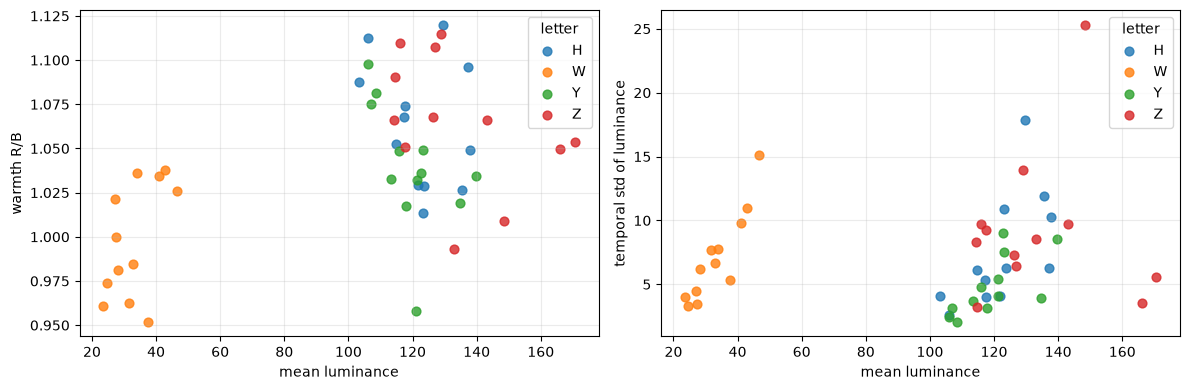


Prior guess to test: Z=noon(zhongwu), W=night(wanshang), H=dusk(huanghun), Y=rain(yinyu)
Step 9 IR detection rates for reference: H 0.97, W 0.68, Y 0.53, Z 1.00


In [15]:
def frame_stats(path, k=25):
    """Whole-frame lighting statistics from k frames spread across a recording."""
    cap = cv2.VideoCapture(str(path))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    lum, warm, sat, spatial, clip, dark = [], [], [], [], [], []
    for i in np.linspace(n * 0.05, n * 0.95, k).astype(int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, fr = cap.read()
        if not ok:
            continue
        small = cv2.resize(fr, (256, 144)).astype(np.float32)
        g = cv2.cvtColor(small.astype(np.uint8), cv2.COLOR_BGR2GRAY).astype(np.float32)
        b, gr, r = small[..., 0].mean(), small[..., 1].mean(), small[..., 2].mean()
        hsv = cv2.cvtColor(small.astype(np.uint8), cv2.COLOR_BGR2HSV)
        lum.append(g.mean())
        warm.append(r / (b + 1e-6))
        sat.append(hsv[..., 1].mean())
        spatial.append(g.std())
        clip.append(float((g > 250).mean()))
        dark.append(float((g < 15).mean()))
    cap.release()
    if not lum:
        return None
    return dict(mean_lum=float(np.mean(lum)),
                temporal_std=float(np.std(lum)),          # sun-angle drift
                spatial_contrast=float(np.mean(spatial)),
                warmth_rb=float(np.mean(warm)),           # artificial light -> high
                saturation=float(np.mean(sat)),
                clip_frac=float(np.mean(clip)),
                dark_frac=float(np.mean(dark)))

rowsL = []
for sname in sorted({r.subject for r in pres}):
    seg = next((s.segment for s in pres if s.subject == sname), None)
    if seg is None:
        continue
    st = frame_stats(PHYS_DIR / sname / seg / 'Video' / 'RGB.mp4')
    if st:
        st.update(subject=sname, segment=seg, lighting=sname[2], vehicle=sname[0])
        rowsL.append(st)

L = pd.DataFrame(rowsL)
cols = ['mean_lum', 'temporal_std', 'spatial_contrast', 'warmth_rb',
        'saturation', 'clip_frac', 'dark_frac']
print(f'n = {len(L)} recordings, {L.lighting.value_counts().to_dict()} per group\n')
print('=== Median statistics by lighting letter ===')
print(L.groupby('lighting')[cols].median().round(3).to_string())
print('\n=== Ranks (1 = lowest) ===')
print(L.groupby('lighting')[cols].median().rank().astype(int).to_string())

print('\n=== Signature matching ===')
med = L.groupby('lighting')[cols].median()
print(f"brightest -> {med.mean_lum.idxmax()} (expect NOON)")
print(f"darkest -> {med.mean_lum.idxmin()} (expect NIGHT)")
print(f"most clipping -> {med.clip_frac.idxmax()} (expect NOON)")
print(f"most dark pixels -> {med.dark_frac.idxmax()} (expect NIGHT)")
print(f"warmest (R/B) -> {med.warmth_rb.idxmax()} (expect NIGHT, artificial light)")
print(f"most temporally -> {med.temporal_std.idxmax()} (expect EARLY MORNING & DUSK)")
print(f"lowest contrast -> {med.spatial_contrast.idxmin()} (expect RAINY & CLOUDY)")
print(f"least saturated -> {med.saturation.idxmin()} (expect RAINY & CLOUDY)")

print('\n=== Within-group spread (is the letter really a condition?) ===')
print(L.groupby('lighting')[['mean_lum', 'warmth_rb']].std().round(3).to_string())
print('Low within-group spread relative to between-group differences confirms')
print('the letter encodes a real acquisition condition rather than noise.')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for lt, sub in L.groupby('lighting'):
    ax[0].scatter(sub.mean_lum, sub.warmth_rb, label=lt, s=40, alpha=0.8)
    ax[1].scatter(sub.mean_lum, sub.temporal_std, label=lt, s=40, alpha=0.8)
ax[0].set_xlabel('mean luminance'); ax[0].set_ylabel('warmth R/B'); ax[0].legend(title='letter')
ax[1].set_xlabel('mean luminance'); ax[1].set_ylabel('temporal std of luminance')
ax[1].legend(title='letter')
for a in ax: a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

print('\nPrior guess to test: Z=noon(zhongwu), W=night(wanshang), H=dusk(huanghun), Y=rain(yinyu)')
print('Step 9 IR detection rates for reference: H 0.97, W 0.68, Y 0.53, Z 1.00')
L_df = L

  ...60/283  (148s)
  ...120/283  (337s)
  ...180/283  (526s)
  ...240/283  (587s)
(614s)  n=283

=== Luminance trend per recording, by lighting letter ===
          median_slope  median_abs_slope  p90_abs_slope  frac_rising  frac_falling  frac_flat  resid
lighting                                                                                            
H                0.301             1.554          5.718        0.441         0.235      0.324  5.618
W               -0.092             0.769          2.552        0.139         0.278      0.583  4.428
Y               -0.214             0.989          3.663        0.222         0.278      0.500  4.671
Z               -0.144             1.517          5.476        0.296         0.366      0.338  5.718

=== Signature reading ===
largest |trend| -> H   (expect EARLY MORNING & DUSK)
flattest -> W
The morning/dusk group pools sunrise and sunset, so it should be the only
group with BOTH a high rising fraction AND a high falling fraction.
H:

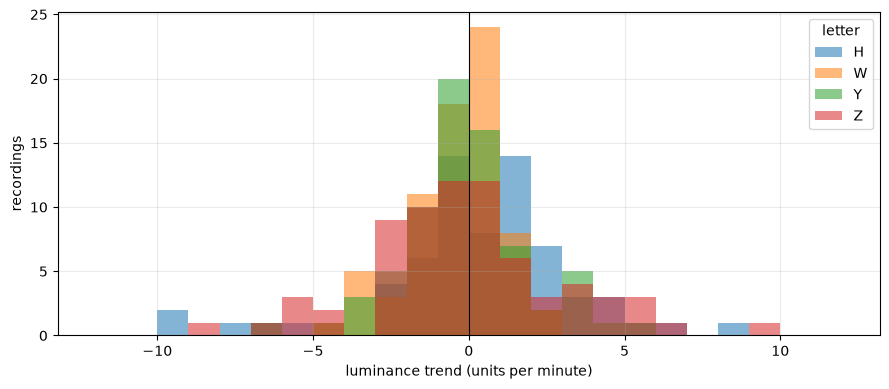


Hypothesis under test:  Z = zao (early morning & dusk),  W = wan (night),
                        Y = yin (rainy & cloudy),  H = hao tianqi (clear noon)


In [16]:
def lum_trend(path, k=25):
    """Linear trend of frame luminance across a recording, in units per minute."""
    cap = cv2.VideoCapture(str(path))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if n < 100:
        cap.release(); return np.nan, np.nan
    idxs = np.linspace(n * 0.03, n * 0.97, k).astype(int)
    t, lum = [], []
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, fr = cap.read()
        if not ok:
            continue
        g = cv2.cvtColor(cv2.resize(fr, (256, 144)), cv2.COLOR_BGR2GRAY)
        t.append(i / FS / 60.0)          # minutes
        lum.append(float(g.mean()))
    cap.release()
    if len(lum) < 8:
        return np.nan, np.nan
    slope = np.polyfit(t, lum, 1)[0]
    resid = np.std(np.array(lum) - np.polyval(np.polyfit(t, lum, 1), t))
    return float(slope), float(resid)

rowsT, t0 = [], time.time()
for i, r in enumerate(pres):
    sl, rs = lum_trend(PHYS_DIR / r.subject / r.segment / 'Video' / 'RGB.mp4')
    rowsT.append({'subject': r.subject, 'segment': r.segment, 'lighting': r.lighting,
                  'slope': sl, 'resid': rs})
    if (i + 1) % 60 == 0:
        print(f'  ...{i+1}/{len(pres)}  ({time.time()-t0:.0f}s)')
T = pd.DataFrame(rowsT).dropna()
print(f'({time.time()-t0:.0f}s)  n={len(T)}\n')

print('=== Luminance trend per recording, by lighting letter ===')
summ = T.groupby('lighting').agg(
    median_slope=('slope', 'median'),
    median_abs_slope=('slope', lambda s: s.abs().median()),
    p90_abs_slope=('slope', lambda s: s.abs().quantile(0.90)),
    frac_rising=('slope', lambda s: (s > 1).mean()),
    frac_falling=('slope', lambda s: (s < -1).mean()),
    frac_flat=('slope', lambda s: (s.abs() <= 1).mean()),
    resid=('resid', 'median')).round(3)
print(summ.to_string())

print('\n=== Signature reading ===')
print(f"largest |trend| -> {summ.median_abs_slope.idxmax()}   (expect EARLY MORNING & DUSK)")
print(f"flattest -> {summ.median_abs_slope.idxmin()}")
print('The morning/dusk group pools sunrise and sunset, so it should be the only')
print('group with BOTH a high rising fraction AND a high falling fraction.')
for lt in sorted(T.lighting.unique()):
    s = summ.loc[lt]
    mixed = min(s.frac_rising, s.frac_falling)
    print(f'{lt}: rising {s.frac_rising:.2f}  falling {s.frac_falling:.2f}  '
          f'flat {s.frac_flat:.2f}   bimodality score {mixed:.2f}')
print(f"\n  highest bimodality -> "
      f"{max(sorted(T.lighting.unique()), key=lambda l: min(summ.loc[l, 'frac_rising'], summ.loc[l, 'frac_falling']))}")

# per-subject consistency: a real time-of-day effect is consistent within a session
print('\n=== Per-subject mean slope (a session drifts as a whole) ===')
ps = T.groupby(['lighting', 'subject']).slope.mean().reset_index()
print(ps.groupby('lighting').slope.agg(['median', 'std',
      lambda s: (s.abs() > 1).mean()]).rename(columns={'<lambda_0>': 'frac_drifting'}).round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
for lt in sorted(T.lighting.unique()):
    ax.hist(T[T.lighting == lt].slope, bins=np.arange(-12, 12.5, 1.0),
            alpha=0.55, label=lt)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('luminance trend (units per minute)'); ax.set_ylabel('recordings')
ax.legend(title='letter'); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

print('\nHypothesis under test:  Z = zao (early morning & dusk),  W = wan (night),')
print('                        Y = yin (rainy & cloudy),  H = hao tianqi (clear noon)')
T_df = T

## Conclusions and preprocessing specification

PhysDrive is characterized end to end, and the two opening questions are answered. It
is a strong, clean HR/BVP source on the hardest realistic domain: the RGB face is
detectable and croppable, and the BVP label - shipped resampled to the 30 Hz frame grid
— provides a frame-synced pulse reference under genuine in-vehicle motion and dynamic
lighting, exactly the well-labelled hard data the screen indicated MCD's ceiling
requires. The shipped RESP channel, however, is **not a usable respiration reference**:
cross-sensor agreement sits at chance (permutation p ~ 0.48), the estimators are
validated as correct and filter-robust, and the channel's energy forms a broad plateau
near half the heart rate rather than a breathing fundamental - consistent with
cardiac/ballistic pickup or placeholder content. The respiration head therefore stays
masked for PhysDrive; the dataset contributes to the HR/BVP corpus, not to RR.

Label quality control and alignment set the loader's requirements. HR and SpO2 carry
device sentinels (HR = 255, SpO2 = 127) and occasional dropouts, usable only as sparse
masked auxiliary references; BVP is the reliable waveform, with BVP_Filt absent on some
recordings, so the raw BVP is stored as the label. Video-to-label alignment is
END-aligned, requiring the leading excess frames to be dropped so the retained frames
match the label length. Segment identity decodes from the folder name (vehicle, gender,
lighting) and the segment suffix (road condition x action state, stationary vs
speaking).

The preprocessing loader (NB_P3_17) therefore, per segment: decodes the RGB video, crops
the face region to 72x72, and END-aligns it to the label length; stores the 30 Hz BVP as
the frame-synced pulse label and ECG, HR and SpO2 as auxiliary references with their
validity masks; drops or masks RESP so it is never consumed as a respiration target;
records the vehicle, gender, lighting, road and action metadata and a per-recording
cardiac quality score as a soft training weight; and writes to the unified Phase-3 HDF5
schema with role = train (HR/BVP), respiration masked.